In [1]:
# Follow the EDA by Almed Tohamy
import pandas as pd
# Load three files into pandas
rppa = None
rna_raw = None
egfrviii = None

for fn in ['mrna_seq_v2_rsem', 'rppa','The_EGFRvIII_Transcriptome_in_glioblastoma_data_public_Zenodo']:
    if fn == "rppa":
        rppa = pd.read_csv(f'../glioblastoma/gbm_tcga_pan_can_atlas_2018/data_{fn}.txt', sep='\t', index_col = 0) 
        print("Shape of RPPA:", rppa.shape)
    if fn == "mrna_seq_v2_rsem":
        rna_raw = pd.read_csv(f'../glioblastoma/gbm_tcga_pan_can_atlas_2018/data_{fn}.txt', sep='\t',low_memory=False)
        print("Shape of RNA-Seq:", rna_raw.shape)
    if 'egfr' in fn.lower():
        egfrviii = pd.read_csv(f'../glioblastoma/{fn}.csv')
        print("Shape of EGFRvIII:", egfrviii.shape)




Shape of RNA-Seq: (20531, 162)
Shape of RPPA: (198, 231)
Shape of EGFRvIII: (858, 45)


In [2]:
import os 
os.getcwd() # check current working directory

'c:\\Users\\Norman\\OMICS_new\\Python_code'

The first part of the ipynb file is completely based on Alhem's initial exploratory analysis. 

In [3]:
rppa.head()

,TCGA-02-0011-01,TCGA-08-0345-01,TCGA-08-0353-01,TCGA-19-1386-01,TCGA-15-1447-01,TCGA-06-0879-01,TCGA-12-0692-01,TCGA-12-1597-01,TCGA-28-1753-01,TCGA-02-0014-01,...,TCGA-19-A60I-01,TCGA-RR-A6KA-01,TCGA-06-A5U0-01,TCGA-19-A6J5-01,TCGA-19-A6J4-01,TCGA-RR-A6KB-01,TCGA-06-A5U1-01,TCGA-06-A7TL-01,TCGA-06-A6S1-01,TCGA-06-A6S0-01
Composite.Element.REF,,,,,,,,,,,,,,,,,,,,,
YWHAE|14-3-3_epsilon,-0.207613,-0.636009,-0.614822,-0.814021,-0.404739,-0.683170,-0.368914,-0.630628,-0.261479,-0.497308,...,-0.931323,-0.562675,-0.658759,-0.663650,-0.514397,-0.062952,-0.732799,-0.551528,-0.552643,-0.666786
EIF4EBP1|4E-BP1,0.656279,-0.110116,0.795610,-0.122043,0.021175,-0.039455,0.148736,0.195686,0.735037,0.574000,...,0.559416,0.624413,-0.387927,0.840756,-0.248578,-0.683082,-0.462129,-0.122321,-0.288098,-0.147660
EIF4EBP1|4E-BP1_pS65,0.543074,0.303296,0.505316,0.549720,0.256577,0.292693,-0.019744,0.625297,0.276694,1.229849,...,0.513167,1.000278,0.499328,0.086153,0.328906,0.860816,0.300206,0.550100,0.238205,0.621720
EIF4EBP1|4E-BP1_pT37T46,1.895562,1.675490,1.811415,2.560177,0.663294,1.912979,1.275898,3.005867,3.398537,3.221768,...,1.765561,1.991205,1.826416,1.731022,1.030846,0.841961,1.207399,1.814400,1.349579,1.131411
TP53BP1|53BP1,1.089430,2.234210,1.827349,2.022301,1.709573,1.926509,0.986573,2.223983,1.742230,2.112393,...,2.507641,-0.120784,2.327586,1.551078,1.976395,1.688886,1.494165,3.101044,2.916305,1.864738


In [4]:
rna_raw.head()

,Hugo_Symbol,Entrez_Gene_Id,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-06-0125-01,TCGA-06-0125-02,TCGA-06-0129-01,...,TCGA-41-3915-01,TCGA-41-4097-01,TCGA-41-5651-01,TCGA-76-4925-01,TCGA-76-4926-01,TCGA-76-4927-01,TCGA-76-4928-01,TCGA-76-4929-01,TCGA-76-4931-01,TCGA-76-4932-01
0,NaN,100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.4604,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,NaN,100133144,3.0732,0.0000,2.9467,15.9952,5.5610,9.9246,3.3758,22.3207,...,8.2279,15.2648,1.2190,12.2160,9.5716,2.4096,10.1709,8.4757,6.1600,0.0000
2,UBE2Q2P2,100134869,6.7611,15.6973,13.9398,14.9571,4.8049,11.6684,3.3862,16.8239,...,10.2174,13.8987,10.3611,17.3596,13.9689,6.4257,6.4812,3.2496,7.9576,9.9502
3,HMGB1P1,10357,54.7036,31.3945,60.3441,91.8238,62.5366,52.1491,41.6125,76.2289,...,35.5731,27.6285,70.0838,108.1350,70.5556,43.0201,42.4584,62.2278,58.8188,60.1990
4,NaN,10431,886.3210,885.7740,1234.8300,470.0000,546.3410,391.9330,419.2460,642.3830,...,512.5160,593.2460,507.6950,531.9330,588.0410,620.8840,533.7420,668.9000,458.3530,499.5020


In [5]:
egfrviii.head()

,Unnamed: 0,X,sample.id,wt.reads.full,vIII.reads.full,n.exon1.spliced.reads.full,EGFRvIII.pct,eligible.for.EGFRvIII.detection,dataset,EGFR.high.expression,...,EGFRvIII.pct.DNA,EGFR.WES.CN,knn.subtype.call,knn.Classical,knn.Mesenchymal,knn.Proneural,svm.subtype.call,svm.Classical,svm.Mesenchymal,svm.Proneural
0,1,1,belob.1,22.0,0.0,22.0,0.0,True,BELOB,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2,belob.10,1186.0,0.0,1186.0,0.0,True,BELOB,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,3,belob.100,129.0,0.0,129.0,0.0,True,BELOB,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,4,belob.102,4.0,0.0,4.0,NaN,False,BELOB,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,5,belob.104,3.0,0.0,3.0,NaN,False,BELOB,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Data cleaning and preprocessing

import re
import numpy as np

# 1) choose the gene column (prefer Hugo_Symbol if present)
gene_col = None
for c in rna_raw.columns:
    if str(c).lower() in ['hugosymbol', 'gene', 'gene_name', 'symbol', 'genes']:
        gene_col = c
        break
if gene_col is None: 
    gene_col = rna_raw.columns[0]
print("the detected gene column is:", gene_col)
# 2) detect TCGA sample columns (TCGA-XX-XXXX-YY...)
tcga_pat = re.compile(r"^TCGA-[A-Z0-9]{2}-[A-Z0-9]{4}-\d{2}", re.IGNORECASE) # this is to detect TCGA sample columns with regex
sample_cols = [c for c in rna_raw.columns if tcga_pat.match(str(c))]

# 3) slim to gene + sample columns, drop NA genes, group duplicate genes by mean
rna_slim = rna_raw[[gene_col]+sample_cols].copy() # this is to create a slim version of rna_raw with only gene and sample columns
rna_slim = rna_slim.dropna(subset=[gene_col]) 
rna_slim = rna_slim.groupby(gene_col, as_index = True).mean(numeric_only  = True) # this is to group duplicate genes by mean

# 4) transpose to samples * genes
rna = rna_slim.T
rna.index.name = "Sample_ID" # set index name, displayed in rna.head()

# 5) harmonize RPPA columns and compute intersection
rppa.columns = pd.Index([c.strip() for c in rppa.columns])
# # sorted() computes the intersection of sample names
common_samples = sorted(set(rppa.columns) & set(rna.index)) # set(rppa.columns) is the set of RPPA sample names, set(rna.index) is the set of RNA sample names (row indices after transpose)

print("Parsed RNA matrix (samples * genes):" , rna.shape)
print("RPPA matrix (features * samples):", rppa.shape)
print("Common samples:", len(common_samples))
print("common_samples example:", common_samples[:5])

the detected gene column is: Hugo_Symbol
Parsed RNA matrix (samples * genes): (160, 20511)
RPPA matrix (features * samples): (198, 231)
Common samples: 77
common_samples example: ['TCGA-02-2485-01', 'TCGA-06-0125-01', 'TCGA-06-0125-02', 'TCGA-06-0129-01', 'TCGA-06-0130-01']


In [7]:
# 6) quick QC counts (before any normalization)
rna_na_total = int(rna.isna().sum().sum()) # total NA cells in rna
rppa_na_rows = int((rppa.isna().sum(axis=1) > 0).sum()) # number of RPPA rows with any NA
rna_zero_var = int((rna.std(axis=0) == 0).sum()) # number of RNA genes with zero variance
rppa_zero_var = int((rppa.std(axis=1) == 0).sum()) # the number of RPPA features with zero variance

print("\nQC:")
print("  RNA total NA cells:", rna_na_total)
print("  RPPA rows with any NA:", rppa_na_rows)
print("  RNA genes with zero variance:", rna_zero_var)
print("  RPPA features with zero variance:", rppa_zero_var)

# 7) show a tiny peek so we can visually confirm structure
print("\nRNA (5 samples × 5 genes):")
display(rna.iloc[:5, :5])

print("\nRPPA (5 features × 5 samples):")
display(rppa.iloc[:5, :5])


QC:
  RNA total NA cells: 0
  RPPA rows with any NA: 8
  RNA genes with zero variance: 533
  RPPA features with zero variance: 0

RNA (5 samples × 5 genes):


Hugo_Symbol,A1BG,A1CF,A2BP1,A2LD1,A2M
Sample_ID,,,,,
TCGA-02-0047-01,125.0070,0.0,244.6300,55.0724,34012.40
TCGA-02-0055-01,391.8040,0.0,137.3510,84.0140,42876.30
TCGA-02-2483-01,271.8520,0.0,111.0290,34.5372,21058.50
TCGA-02-2485-01,83.9429,0.0,257.1430,126.2860,7798.53
TCGA-02-2486-01,108.2560,0.0,4.2683,190.5300,40971.40



RPPA (5 features × 5 samples):


,TCGA-02-0011-01,TCGA-08-0345-01,TCGA-08-0353-01,TCGA-19-1386-01,TCGA-15-1447-01
Composite.Element.REF,,,,,
YWHAE|14-3-3_epsilon,-0.207613,-0.636009,-0.614822,-0.814021,-0.404739
EIF4EBP1|4E-BP1,0.656279,-0.110116,0.795610,-0.122043,0.021175
EIF4EBP1|4E-BP1_pS65,0.543074,0.303296,0.505316,0.549720,0.256577
EIF4EBP1|4E-BP1_pT37T46,1.895562,1.675490,1.811415,2.560177,0.663294
TP53BP1|53BP1,1.089430,2.234210,1.827349,2.022301,1.709573


In [8]:
# Normalize (z-score) and clean
# RPPA: z-score each feature (row)
rppa_z = rppa.sub(rppa.mean(axis = 1), axis = 0) # rppa.sub() subtracts the mean of each row from each element in that row)
rppa_z = rppa_z.div(rppa.std(axis = 1).replace(0, np.nan), axis = 0) # rppa.div() divides each element in a row by the std of that row; replace(0, np.nan) avoids division by zero

# RNA: z-score each gene (column)
rna_z = (rna - rna.mean(axis = 0)) / rna.std(axis = 0).replace(0, np.nan)

# Subset to common samples
rppa_z = rppa_z[common_samples]
rna_z  = rna_z.loc[common_samples]

print("RPPA_z: ", rppa_z.shape)
print("RNA_z: ", rna_z.shape)

print("\n Missing values check:")
print(" RPPA_z any NaN:", rppa_z.isna().any().any())
print(" RNA_z any NaN:", rna_z.isna().any().any())


RPPA_z:  (198, 77)
RNA_z:  (77, 20511)

 Missing values check:
 RPPA_z any NaN: True
 RNA_z any NaN: True


In [9]:
#Strict numeric clean, impute, drop-zero-var, z-score, PCA (RPPA)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Start from RPPA restricted to common samples
R = rppa.loc[:, common_samples].copy()

# 1) Force numeric (coerce non-numeric to NaN)
R = R.apply(pd.to_numeric, errors="coerce")

# 2) Drop rows that are entirely NaN
n_allna_before = int((R.isna().all(axis=1)).sum())
R = R.loc[~R.isna().all(axis=1)]
print("Rows dropped (all-NaN):", n_allna_before)

# 3) Impute remaining NaNs per row with the row median
R_imp = R.apply(lambda row: row.fillna(row.median()), axis=1)

# 4) Drop rows that are constant after imputation (std == 0)
row_std = R_imp.std(axis=1)
n_const = int((row_std == 0).sum())
R_imp = R_imp.loc[row_std > 0]
print("Rows dropped (zero-variance):", n_const)

# 5) Z-score per row
R_z = R_imp.sub(R_imp.mean(axis=1), axis=0)
R_z = R_z.div(R_imp.std(axis=1), axis=0)



# 6) Final guard: replace any residual NaN with 0
had_nan = bool(R_z.isna().any().any())
R_z = R_z.fillna(0.0)
print("Had NaN after z-score (pre-fill)?", had_nan)
print("Any NaN now?:", bool(R_z.isna().any().any()))





Rows dropped (all-NaN): 7
Rows dropped (zero-variance): 0
Had NaN after z-score (pre-fill)? False
Any NaN now?: False


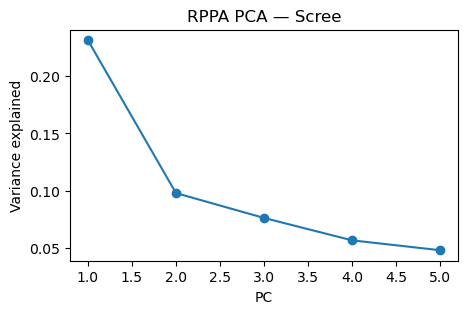

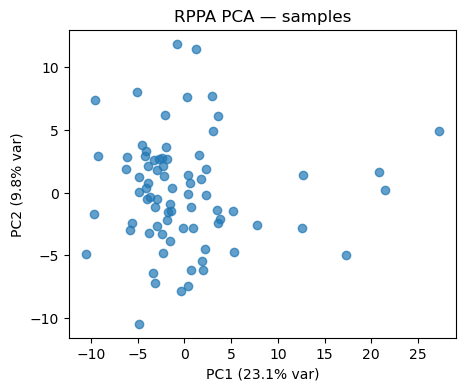

Top 5 PC1 loadings:
Composite.Element.REF
RAB11A RAB11B|Rab11    0.132349
MS4A1|CD20             0.128079
GATA3|GATA3            0.127382
CLDN7|Claudin-7        0.125736
RAD51|Rad51            0.120387
dtype: float64

Bottom 5 PC1 loadings:
Composite.Element.REF
GSK3A GSK3B|GSK3-alpha-beta_pS21_S9   -0.113736
AKT1 AKT2 AKT3|Akt                    -0.115252
MTOR|mTOR                             -0.117196
CTNNB1|beta-Catenin                   -0.118483
TSC2|Tuberin                          -0.129087
dtype: float64


In [10]:
# 7) PCA (samples x features)
X = R_z.T.values
pca_rppa = PCA(n_components=5, random_state=0).fit(X)
scores = pca_rppa.transform(X)

# Scree
plt.figure(figsize=(5,3))
plt.plot(range(1,6), pca_rppa.explained_variance_ratio_, marker='o')
plt.xlabel("PC")
plt.ylabel("Variance explained") # the ratio of sigma_k^2/sum(sigma_j^2)
plt.title("RPPA PCA — Scree")
plt.show()

# PC1 vs PC2
plt.figure(figsize=(5,4))
plt.scatter(scores[:,0], scores[:,1], alpha=0.7)
plt.xlabel(f"PC1 ({pca_rppa.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_rppa.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("RPPA PCA — samples")
plt.show()

# Loadings for PC1 (feature contributions)
pc1_load = pd.Series(pca_rppa.components_[0], index=R_z.index).sort_values(ascending=False)
print("Top 5 PC1 loadings:")
print(pc1_load.head(5))
print("\nBottom 5 PC1 loadings:")
print(pc1_load.tail(5))

In [11]:
pca_rppa.components_

array([[ 1.54572997e-02,  3.43510417e-02, -5.20688938e-02,
        -8.28344666e-02, -1.07368116e-01, -1.08663802e-01,
        -1.12594059e-01, -1.15252442e-01, -6.28646058e-02,
        -2.73519952e-02, -8.13218910e-02, -1.08539833e-01,
        -1.28641877e-02, -2.37717675e-02, -1.02848586e-01,
         1.07984180e-01, -1.28448644e-02, -4.14847442e-02,
         7.92021443e-02,  4.51525907e-02, -1.18482864e-01,
         1.16919397e-01, -2.72966060e-02,  1.69195340e-02,
        -1.09642194e-02,  1.05613189e-01,  7.80542677e-02,
        -2.05252247e-02,  7.14778828e-02,  1.17605011e-01,
         7.01826508e-02,  8.05861180e-02,  6.60179636e-02,
         8.68730026e-02,  1.06534165e-01,  6.52183104e-03,
        -2.62503677e-02,  8.23242794e-02, -3.99833217e-02,
         1.25736328e-01,  9.35153243e-02, -2.01236787e-02,
         1.10930759e-01,  2.98086320e-02, -2.53987593e-02,
        -6.32926678e-02,  1.60963064e-02, -3.04884519e-02,
        -4.84629242e-02, -6.99695386e-02, -4.54070780e-0

RNA high-variance subset: (77, 2000)


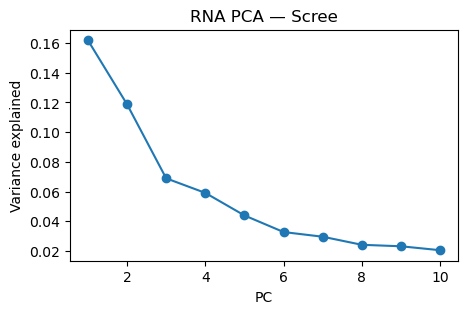

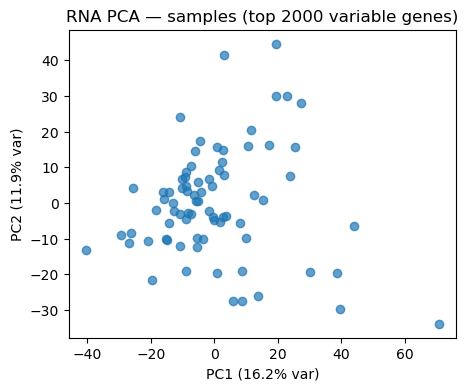

Top 5 PC1 loadings (RNA):
Hugo_Symbol
OST4       0.048872
ATP5E      0.048728
SELENOF    0.048544
RAP1B      0.048429
ARPC3      0.048328
dtype: float64

Bottom 5 PC1 loadings (RNA):
Hugo_Symbol
FAM168B   -0.042828
NUMA1     -0.042971
BAT2L1    -0.043129
SRRM2     -0.044467
DCAF7     -0.045619
dtype: float64 

Top 5 PC2 loadings (RNA):
Hugo_Symbol
MVP       0.054774
PLXND1    0.054115
TGOLN2    0.052224
MYH9      0.050096
TPP1      0.049694
dtype: float64

Bottom 5 PC2 loadings (RNA):
Hugo_Symbol
STMN1     -0.044790
C1orf61   -0.045386
FXYD6     -0.045916
MATR3     -0.048935
GPM6A     -0.050352
dtype: float64 



In [12]:
#PCA on RNA (restrict to high-variance genes)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Subset to common samples
rna_sub = rna.loc[common_samples] # extract in the rows corresponding to common samples
# rna_sub = rna_z
# Compute variance per gene
gene_var = rna_sub.var(axis=0)
top_genes = gene_var.sort_values(ascending=False).head(2000).index # top 2000 most variable genes
rna_hv = rna_sub[top_genes] # subset to these genes

# Z-score each gene (re-normalize within this subset)
rna_hv_z = (rna_hv - rna_hv.mean(axis=0)) / rna_hv.std(axis=0).replace(0, np.nan)
rna_hv_z = rna_hv_z.fillna(0.0)

print("RNA high-variance subset:", rna_hv_z.shape)

# PCA
X_rna = rna_hv_z.values
pca_rna = PCA(n_components=10, random_state=0).fit(X_rna)
rna_embed = pca_rna.transform(X_rna)

# Scree
plt.figure(figsize=(5,3))
plt.plot(range(1,11), pca_rna.explained_variance_ratio_, marker='o')
plt.xlabel("PC")
plt.ylabel("Variance explained")
plt.title("RNA PCA — Scree")
plt.show()

# PC1 vs PC2 scatter
plt.figure(figsize=(5,4))
plt.scatter(rna_embed[:,0], rna_embed[:,1], alpha=0.7)
plt.xlabel(f"PC1 ({pca_rna.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_rna.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("RNA PCA — samples (top 2000 variable genes)")
plt.show()

# Top/bottom loadings for PC1
pc1_load_rna = pd.Series(pca_rna.components_[0], index=rna_hv_z.columns).sort_values(ascending=False)
print("Top 5 PC1 loadings (RNA):")
print(pc1_load_rna.head(5))
print("\nBottom 5 PC1 loadings (RNA):")
print(pc1_load_rna.tail(5), "\n")

# Top/bottom loadings for PC2
pc2_load_rna = pd.Series(pca_rna.components_[1], index=rna_hv_z.columns).sort_values(ascending=False)
print("Top 5 PC2 loadings (RNA):")
print(pc2_load_rna.head(5))
print("\nBottom 5 PC2 loadings (RNA):")
print(pc2_load_rna.tail(5), "\n")

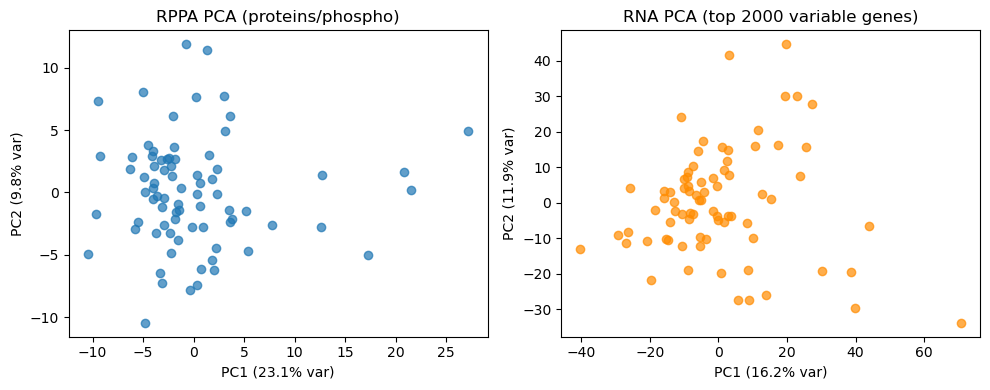

In [13]:
#Side-by-side PCA plots for RPPA vs RNA

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# RPPA scatter
axes[0].scatter(scores[:,0], scores[:,1], alpha=0.7)
axes[0].set_xlabel(f"PC1 ({pca_rppa.explained_variance_ratio_[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca_rppa.explained_variance_ratio_[1]*100:.1f}% var)")
axes[0].set_title("RPPA PCA (proteins/phospho)")

# RNA scatter
axes[1].scatter(rna_embed[:,0], rna_embed[:,1], alpha=0.7, color="darkorange")
axes[1].set_xlabel(f"PC1 ({pca_rna.explained_variance_ratio_[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca_rna.explained_variance_ratio_[1]*100:.1f}% var)")
axes[1].set_title("RNA PCA (top 2000 variable genes)")

plt.tight_layout()
plt.show()

RNA–RPPA sample distance correlation: r=0.332, p=4.97e-76


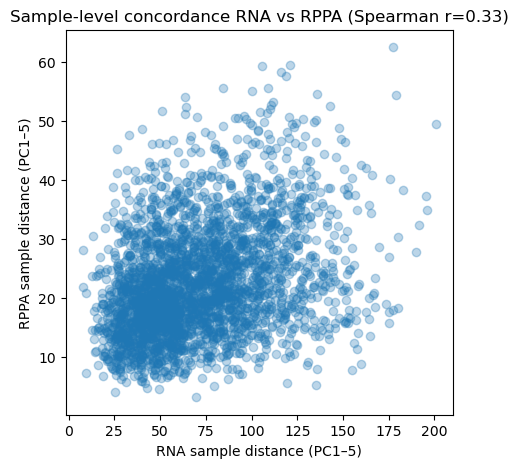

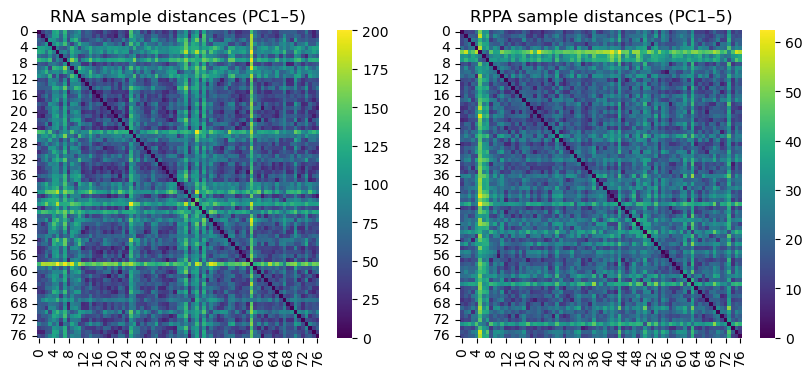

In [14]:
#Compare sample distances across RNA vs RPPA

from sklearn.metrics import pairwise_distances
import seaborn as sns
import matplotlib.pyplot as plt

# Use PCA scores (PC1–PC5) for RNA and RPPA
p = 1
rna_dist = pairwise_distances(rna_embed[:, :5], metric='minkowski', p=p) ** p 
rppa_dist = pairwise_distances(scores[:, :5], metric='minkowski', p=p) ** p

# Flatten upper triangles for correlation
mask = np.triu(np.ones(rna_dist.shape), k=1).astype(bool)
rna_flat = rna_dist[mask]
rppa_flat = rppa_dist[mask]

# Correlation between distance structures
from scipy.stats import spearmanr
corr, pval = spearmanr(rna_flat, rppa_flat)

print(f"RNA–RPPA sample distance correlation: r={corr:.3f}, p={pval:.2e}")

# Scatterplot of distances
plt.figure(figsize=(5,5))
plt.scatter(rna_flat, rppa_flat, alpha=0.3)
plt.xlabel("RNA sample distance (PC1–5)")
plt.ylabel("RPPA sample distance (PC1–5)")
plt.title(f"Sample-level concordance RNA vs RPPA (Spearman r={corr:.2f})")
plt.show()

# Heatmap comparison
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.heatmap(rna_dist, cmap="viridis", ax=axes[0])
axes[0].set_title("RNA sample distances (PC1–5)")
sns.heatmap(rppa_dist, cmap="viridis", ax=axes[1])
axes[1].set_title("RPPA sample distances (PC1–5)")
plt.show()



In [15]:
print("The shape of rna_dist is: ", rna_dist.shape)

The shape of rna_dist is:  (77, 77)


Correlated features: (174, 6)
       Gene           RPPA_feature  PearsonR          Pval   N     log10P
168   ANXA1        ANXA1|Annexin-1  0.805864  9.624372e-19  77  18.016628
39    CCNE1        CCNE1|Cyclin_E1  0.752473  3.019904e-15  77  14.520007
21      KIT              KIT|c-Kit  0.740998  1.310469e-14  77  13.882573
62   IGFBP2          IGFBP2|IGFBP2  0.726061  7.919237e-14  77  13.101317
118     SYK                SYK|Syk  0.710027  4.811975e-13  77  12.317677
124    YAP1         YAP1|YAP_pS127  0.687212  5.134689e-12  77  11.289486
27     CAV1        CAV1|Caveolin-1  0.664862  4.275070e-11  77  10.369057
172    MSH6              MSH6|MSH6  0.664479  4.426412e-11  77  10.353948
72   ERRFI1           ERRFI1|MIG-6  0.663093  5.017302e-11  77  10.299530
163  SQSTM1  SQSTM1|p62-LCK-ligand  0.659043  7.209124e-11  77  10.142118


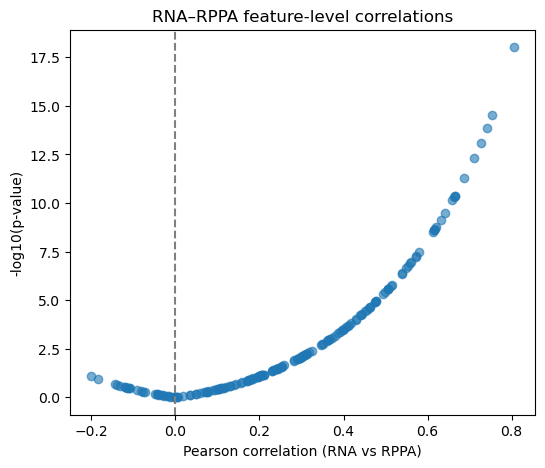

In [16]:
#Feature-level correlation (RNA vs RPPA)

from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Match features: extract gene names from RPPA (before the '|')
rppa_genes = rppa.index.to_series().str.split("|").str[0]
common_genes = rppa_genes[rppa_genes.isin(rna.columns)].unique()

results = []
for g in common_genes:
    # RNA vector
    rna_vec = rna_z[g].loc[common_samples]
    # All RPPA rows mapping to this gene
    rows = rppa.index[rppa.index.str.startswith(g+"|")]
    for row in rows:
        rppa_vec = rppa_z.loc[row, common_samples]
        if rna_vec.std() > 0 and rppa_vec.std() > 0:
            r, p = pearsonr(rna_vec, rppa_vec)
            results.append((g, row, r, p, len(common_samples)))

res_df = pd.DataFrame(results, columns=["Gene","RPPA_feature","PearsonR","Pval","N"])
res_df["log10P"] = -np.log10(res_df["Pval"])

print("Correlated features:", res_df.shape)
print(res_df.sort_values("PearsonR", ascending=False).head(10))

# Volcano plot
plt.figure(figsize=(6,5))
plt.scatter(res_df["PearsonR"], res_df["log10P"], alpha=0.6)
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("Pearson correlation (RNA vs RPPA)")
plt.ylabel("-log10(p-value)")
plt.title("RNA–RPPA feature-level correlations")
plt.show()


Top 10 correlated genes/features:


,Gene,RPPA_feature,PearsonR
168,ANXA1,ANXA1|Annexin-1,0.805864
39,CCNE1,CCNE1|Cyclin_E1,0.752473
21,KIT,KIT|c-Kit,0.740998
62,IGFBP2,IGFBP2|IGFBP2,0.726061
118,SYK,SYK|Syk,0.710027
124,YAP1,YAP1|YAP_pS127,0.687212
27,CAV1,CAV1|Caveolin-1,0.664862
172,MSH6,MSH6|MSH6,0.664479
72,ERRFI1,ERRFI1|MIG-6,0.663093
163,SQSTM1,SQSTM1|p62-LCK-ligand,0.659043


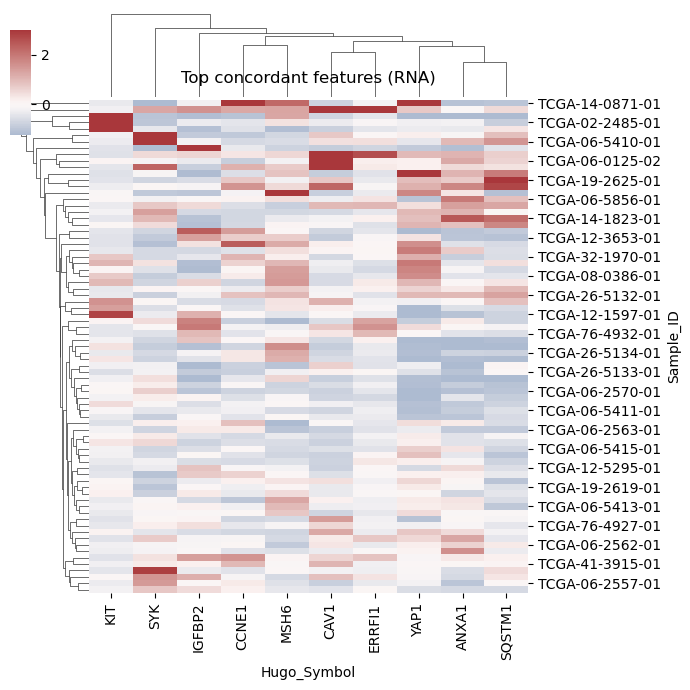

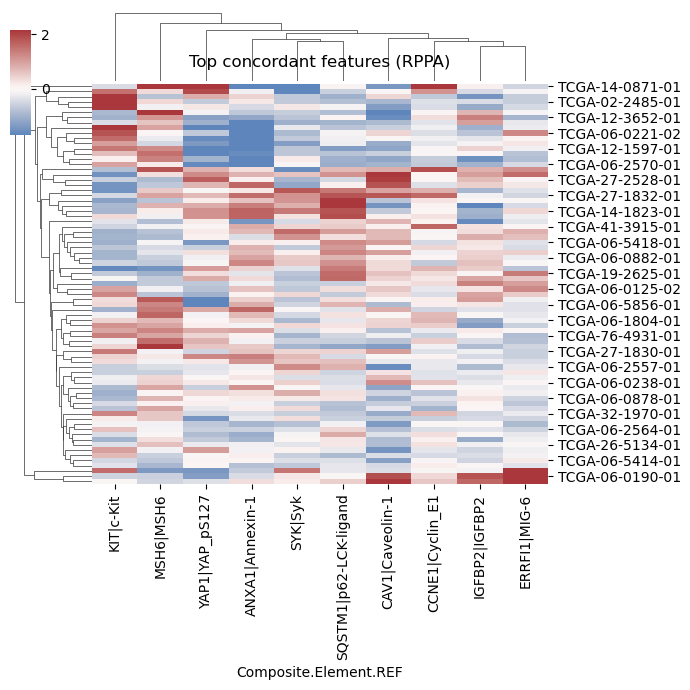

Top concordant features shapes — RNA (77, 10), RPPA (77, 10)
Bottom 10 correlated genes/features:


,Gene,RPPA_feature,PearsonR
95,PDK1,PDK1|PDK1,-0.110571
159,TSC1,TSC1|TSC1,-0.112266
17,CTNNB1,CTNNB1|beta-Catenin,-0.116205
145,NRAS,NRAS|N-Ras,-0.118940
98,PRKCD,PRKCD|PKC-delta_pS664,-0.119709
126,YBX1,YBX1|YB-1_pS102,-0.132462
127,ARAF,ARAF|A-Raf_pS299,-0.137952
170,ERCC1,ERCC1|ERCC1,-0.143944
2,EIF4EBP1,EIF4EBP1|4E-BP1_pS65,-0.183269
113,SRC,SRC|Src_pY416,-0.199917


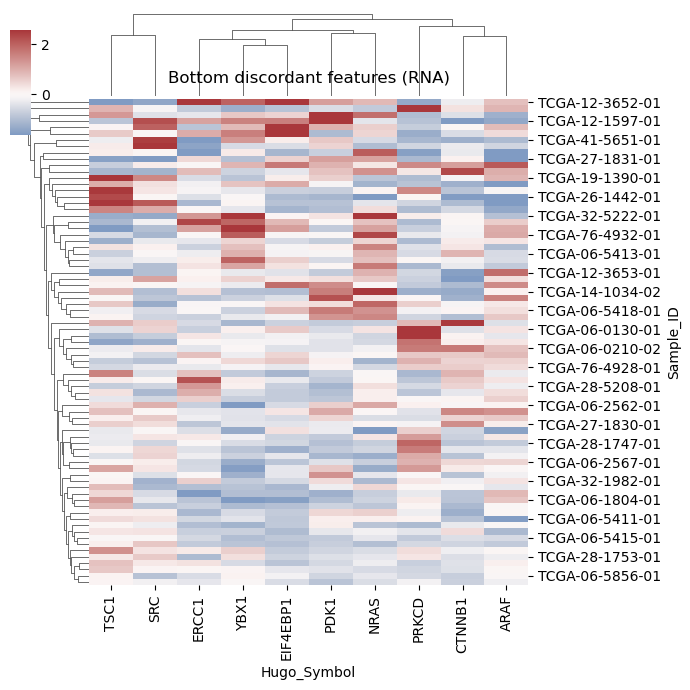

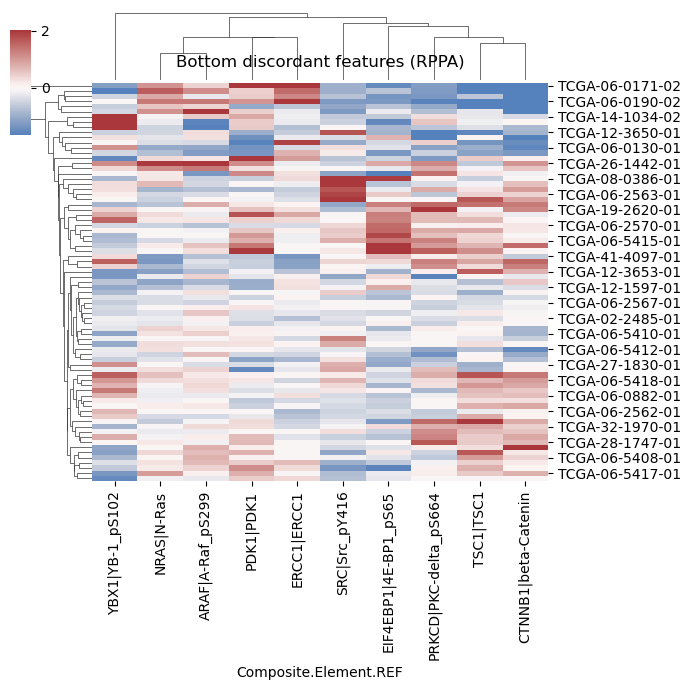

Bottom discordant features shapes — RNA (77, 10), RPPA (77, 10)


In [17]:
#Heatmaps of top concordant and discordant features

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sort by correlation
res_sorted = res_df.sort_values("PearsonR", ascending=False)

# Top 10 concordant
top10 = res_sorted.head(10).copy()
# Bottom 10 discordant (lowest correlations)
bot10 = res_sorted.tail(10).copy()

def _prep_rna_mat(genes):
    # keep only genes that exist in rna_z
    genes = [g for g in genes if g in rna_z.columns]
    M = rna_z.loc[common_samples, genes]          # samples × genes
    # drop duplicate columns if any
    M = M.loc[:, ~M.columns.duplicated()]
    # drop columns/rows that are all NaN or zero variance
    keep_cols = (M.notna().any(axis=0)) & (M.std(axis=0, ddof=1) > 0)
    M = M.loc[:, keep_cols]
    keep_rows = (M.notna().any(axis=1)) & (M.std(axis=1, ddof=1) > 0)
    M = M.loc[keep_rows]
    return M

def _prep_rppa_mat(features):
    feats = [f for f in features if f in rppa_z.index]
    M = rppa_z.loc[feats, common_samples].T        # samples × features
    # drop duplicate columns if any
    M = M.loc[:, ~M.columns.duplicated()]
    # drop columns/rows that are all NaN or zero variance
    keep_cols = (M.notna().any(axis=0)) & (M.std(axis=0, ddof=1) > 0)
    M = M.loc[:, keep_cols]
    keep_rows = (M.notna().any(axis=1)) & (M.std(axis=1, ddof=1) > 0)
    M = M.loc[keep_rows]
    return M

def plot_heatmap_pair(subset, title_prefix, tag):
    genes = subset["Gene"].tolist()
    feats = subset["RPPA_feature"].tolist()

    M_rna  = _prep_rna_mat(genes)
    M_rppa = _prep_rppa_mat(feats)

    # If a matrix ends up empty, report and skip plotting to avoid blank figs
    if M_rna.shape[1] == 0 or M_rna.shape[0] == 0:
        print(f"[WARN] RNA matrix is empty for {title_prefix} (after cleaning).")
    else:
        g1 = sns.clustermap(
            M_rna, cmap="vlag", center=0, robust=True,
            figsize=(7,7), dendrogram_ratio=(.15,.15),
            cbar_pos=(0.02, .8, .03, .15)
        )
        g1.ax_heatmap.set_title(f"{title_prefix} (RNA)", pad=12)
        plt.savefig(f"heatmap_{tag}_RNA.png", dpi=150, bbox_inches="tight")
        plt.show()

    if M_rppa.shape[1] == 0 or M_rppa.shape[0] == 0:
        print(f"[WARN] RPPA matrix is empty for {title_prefix} (after cleaning).")
    else:
        g2 = sns.clustermap(
            M_rppa, cmap="vlag", center=0, robust=True,
            figsize=(7,7), dendrogram_ratio=(.15,.15),
            cbar_pos=(0.02, .8, .03, .15)
        )
        g2.ax_heatmap.set_title(f"{title_prefix} (RPPA)", pad=12)
        plt.savefig(f"heatmap_{tag}_RPPA.png", dpi=150, bbox_inches="tight")
        plt.show()

    # Return shapes so you can sanity-check
    print(f"{title_prefix} shapes — RNA {M_rna.shape}, RPPA {M_rppa.shape}")

print("Top 10 correlated genes/features:")
display(top10[["Gene","RPPA_feature","PearsonR"]])
plot_heatmap_pair(top10, "Top concordant features", "top_concordant")

print("Bottom 10 correlated genes/features:")
display(bot10[["Gene","RPPA_feature","PearsonR"]])
plot_heatmap_pair(bot10, "Bottom discordant features", "bottom_discordant")


Below are some exploratory analysis by Wenyan Luo. I tried ISOMAP and diffusion map embedding of the common samples onto 2D planes to get some sense of the data's shape. 

In [18]:
# ISOMAP embedding
import numpy as np
from sklearn.manifold import Isomap

# Fit ISOMAP to RPPA data
isomap = Isomap(n_components=2, n_neighbors=10)
X_rppa = R_z.T.values
isomap.fit(X_rppa)
isomap_embedding_rppa = isomap.transform(X_rppa)

print("The shape of rppa_z is:", X_rppa.shape)
print("The shape of isomap_embedding_rppa is:", isomap_embedding_rppa.shape)

# Fit ISOMAP to RNA data
isomap = Isomap(n_components=2, n_neighbors=10)
X_rna = rna_hv_z.values
isomap.fit(X_rna)
isomap_embedding_rna = isomap.transform(X_rna)

print("The shape of rna_hv_z is:", X_rna.shape)
print("The shape of isomap_embedding_rna is:", isomap_embedding_rna.shape)

c:\Users\Norman\miniconda3\envs\erdos_ds_environment\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


The shape of rppa_z is: (77, 191)
The shape of isomap_embedding_rppa is: (77, 2)
The shape of rna_hv_z is: (77, 2000)
The shape of isomap_embedding_rna is: (77, 2)


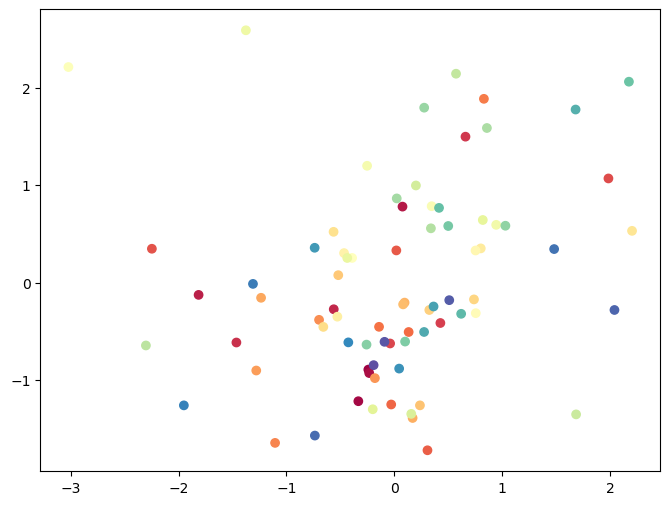

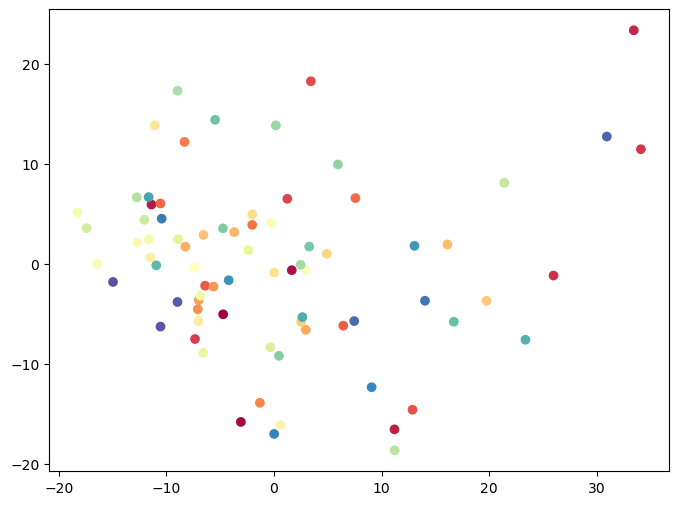

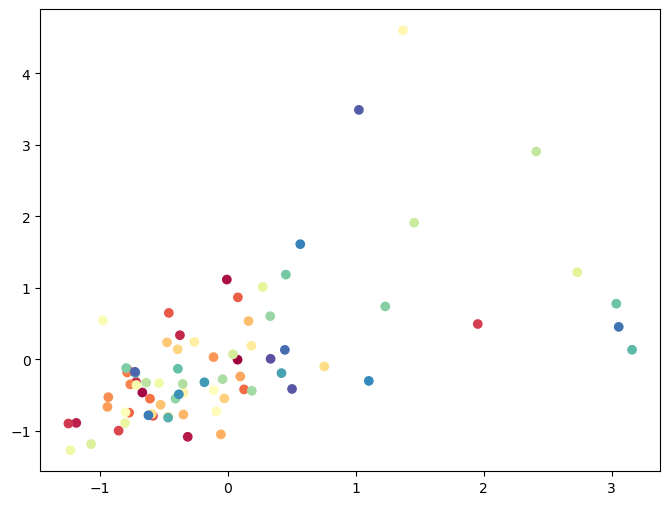

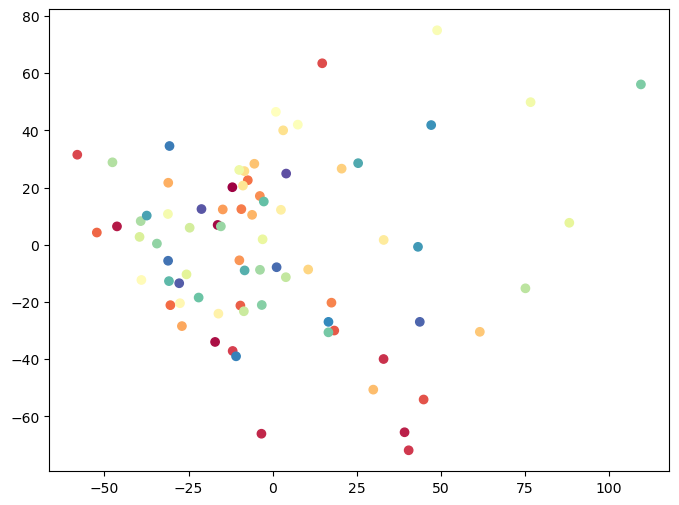

In [19]:
# define a color array based on sample index or a label
colors = np.linspace(0, 1, len(X_rppa))   # or e.g. colors = y if you have class labels

# Plot RPPA data and its ISOMAP embedding
# Plot original RPPA data
plt.figure(figsize=(8, 6))
plt.scatter(X_rppa[:, 0], X_rppa[:, 1], c=colors, cmap='Spectral')
plt.figure(figsize=(8, 6))
plt.scatter(isomap_embedding_rppa[:, 0], isomap_embedding_rppa[:, 1], c=colors, cmap='Spectral')

# Plot RNA data and its ISOMAP embedding
plt.figure(figsize=(8, 6))
plt.scatter(X_rna[:, 0], X_rna[:, 1], c=colors, cmap='Spectral')
plt.figure(figsize=(8, 6))
plt.scatter(isomap_embedding_rna[:, 0], isomap_embedding_rna[:, 1], c=colors, cmap='Spectral')



C:\Users\Norman\AppData\Local\Temp\ipykernel_19408\2412056385.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_rppa[:, 0], X_rppa[:, 1], c="blue", cmap='Spectral', label='Original space', alpha=0.6)
C:\Users\Norman\AppData\Local\Temp\ipykernel_19408\2412056385.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(isomap_embedding_rppa[:, 0], isomap_embedding_rppa[:, 1],


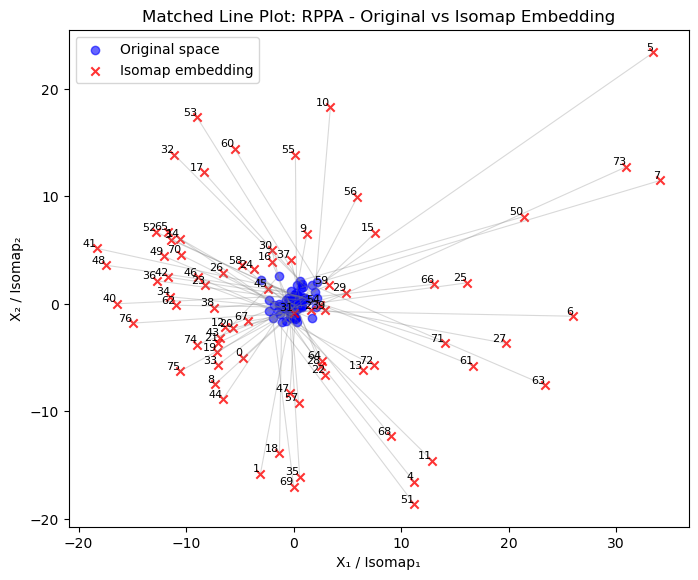

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Example colors (you already have these)
colors = np.linspace(0, 1, len(X_rppa))

# --- Plot RPPA original vs. Isomap embedding with connecting lines ---
plt.figure(figsize=(8, 8))
plt.scatter(X_rppa[:, 0], X_rppa[:, 1], c="blue", cmap='Spectral', label='Original space', alpha=0.6)
plt.scatter(isomap_embedding_rppa[:, 0], isomap_embedding_rppa[:, 1],
            c="red", cmap='Spectral', marker='x', label='Isomap embedding', alpha=0.8)

# Draw lines connecting corresponding points
for i in range(0, len(X_rppa), 1):  # every 5th to avoid clutter; remove the step for all points
    plt.plot([X_rppa[i, 0], isomap_embedding_rppa[i, 0]],
             [X_rppa[i, 1], isomap_embedding_rppa[i, 1]],
             color='gray', alpha=0.3, linewidth=0.8)

# Add number labels for each data point
for i in range(len(X)):
    plt.text(isomap_embedding_rppa[i, 0],
             isomap_embedding_rppa[i, 1],
             str(i),                 # label = index number
             fontsize=8,
             ha='right', va='bottom')
plt.legend()
plt.title("Matched Line Plot: RPPA - Original vs Isomap Embedding")
plt.xlabel("X₁ / Isomap₁")
plt.ylabel("X₂ / Isomap₂")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


C:\Users\Norman\AppData\Local\Temp\ipykernel_19408\4239245724.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_rna[:, 0], X_rna[:, 1], c="blue", cmap='Spectral', label='Original space', alpha=0.6)
C:\Users\Norman\AppData\Local\Temp\ipykernel_19408\4239245724.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(isomap_embedding_rna[:, 0], isomap_embedding_rna[:, 1],


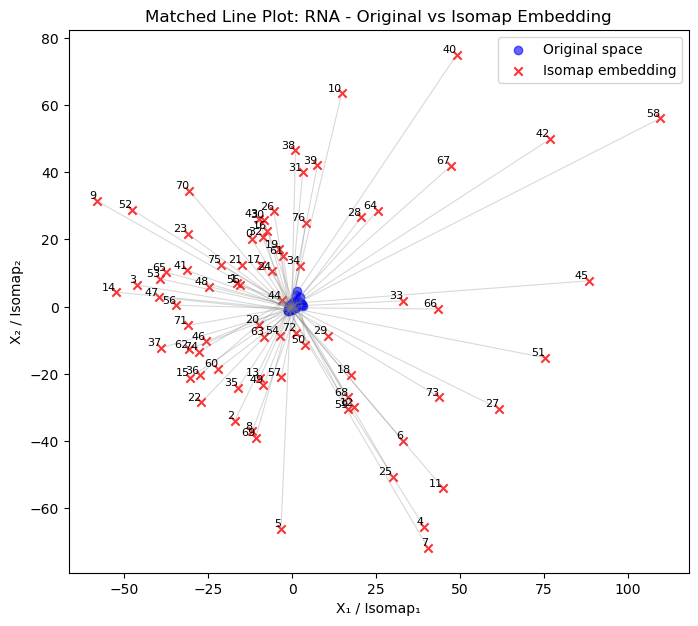

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Example colors (you already have these)
colors = np.linspace(0, 1, len(X_rna))

# --- Plot RNA original vs. Isomap embedding with connecting lines ---
plt.figure(figsize=(8, 8))
plt.scatter(X_rna[:, 0], X_rna[:, 1], c="blue", cmap='Spectral', label='Original space', alpha=0.6)
plt.scatter(isomap_embedding_rna[:, 0], isomap_embedding_rna[:, 1],
            c="red", cmap='Spectral', marker='x', label='Isomap embedding', alpha=0.8)

# Draw lines connecting corresponding points
for i in range(0, len(X_rna), 1):  # every 5th to avoid clutter; remove the step for all points
    plt.plot([X_rna[i, 0], isomap_embedding_rna[i, 0]],
             [X_rna[i, 1], isomap_embedding_rna[i, 1]],
             color='gray', alpha=0.3, linewidth=0.8)
# Add number labels for each data point
for i in range(len(X_rna)):
    plt.text(isomap_embedding_rna[i, 0],
             isomap_embedding_rna[i, 1],
             str(i),                 # label = index number
             fontsize=8,
             ha='right', va='bottom')
plt.legend()
plt.title("Matched Line Plot: RNA - Original vs Isomap Embedding")
plt.xlabel("X₁ / Isomap₁")
plt.ylabel("X₂ / Isomap₂")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

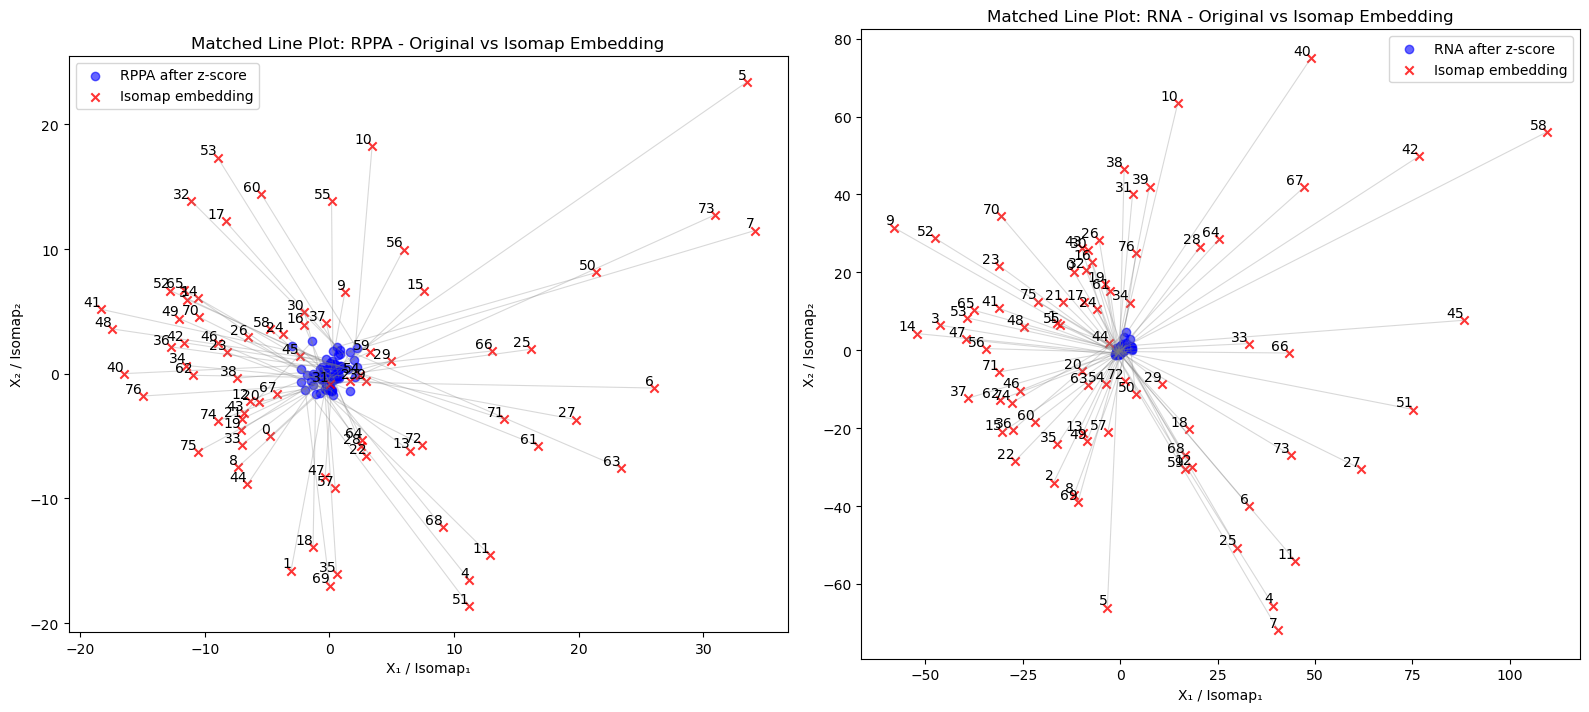

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Example colors
colors_rppa = np.linspace(0, 1, len(X_rppa))
colors_rna  = np.linspace(0, 1, len(X_rna))

# --- Create 1×2 subplot layout ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ===== (1) RPPA matched-line plot =====
ax = axes[0]
ax.scatter(X_rppa[:, 0], X_rppa[:, 1], c="blue", alpha=0.6, label='RPPA after z-score')
ax.scatter(isomap_embedding_rppa[:, 0], isomap_embedding_rppa[:, 1],
           c="red", marker='x', alpha=0.8, label='Isomap embedding')

for i in range(0, len(X_rppa), 1):
    ax.plot([X_rppa[i, 0], isomap_embedding_rppa[i, 0]],
            [X_rppa[i, 1], isomap_embedding_rppa[i, 1]],
            color='gray', alpha=0.3, linewidth=0.8)

# Number labels
for i in range(len(X_rppa)):
    ax.text(isomap_embedding_rppa[i, 0], isomap_embedding_rppa[i, 1],
            str(i), fontsize=10, ha='right', va='bottom')

ax.set_title("Matched Line Plot: RPPA - Original vs Isomap Embedding")
ax.set_xlabel("X₁ / Isomap₁")
ax.set_ylabel("X₂ / Isomap₂")
ax.legend()
ax.set_aspect('equal', adjustable='box')


# ===== (2) RNA matched-line plot =====
ax = axes[1]
ax.scatter(X_rna[:, 0], X_rna[:, 1], c="blue", alpha=0.6, label='RNA after z-score')
ax.scatter(isomap_embedding_rna[:, 0], isomap_embedding_rna[:, 1],
           c="red", marker='x', alpha=0.8, label='Isomap embedding')

for i in range(0, len(X_rna), 1):
    ax.plot([X_rna[i, 0], isomap_embedding_rna[i, 0]],
            [X_rna[i, 1], isomap_embedding_rna[i, 1]],
            color='gray', alpha=0.3, linewidth=0.8)

# Number labels
for i in range(len(X_rna)):
    ax.text(isomap_embedding_rna[i, 0], isomap_embedding_rna[i, 1],
            str(i), fontsize=10, ha='right', va='bottom')

ax.set_title("Matched Line Plot: RNA - Original vs Isomap Embedding")
ax.set_xlabel("X₁ / Isomap₁")
ax.set_ylabel("X₂ / Isomap₂")
ax.legend()
ax.set_aspect('equal', adjustable='box')

# --- Layout adjustment ---
plt.tight_layout()
plt.show()


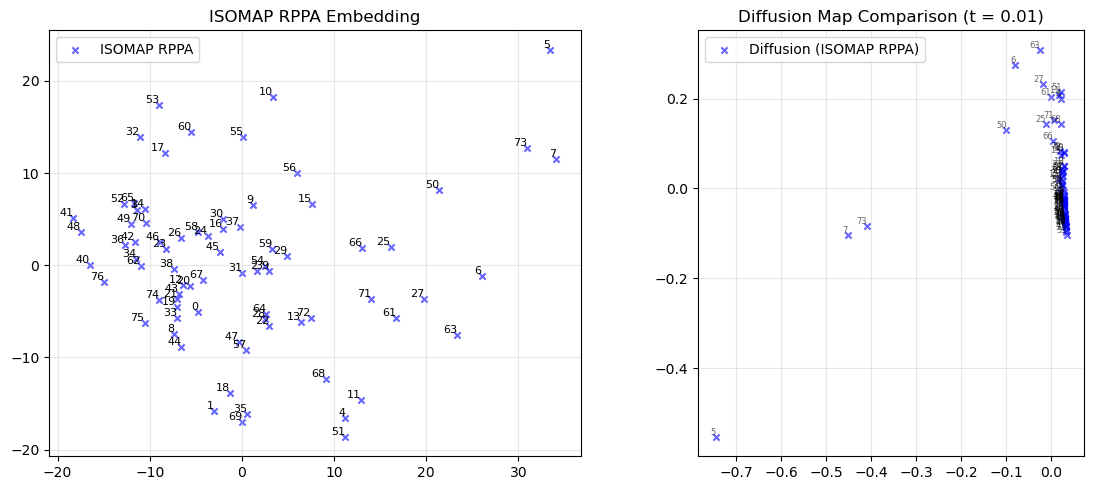

In [23]:
# Implement Diffusion Maps of the ISOMAP embedded data

# Diffusion Map functions 
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.sparse.linalg import eigs

def diffusion_map_fit(X, n_components=2, epsilon=None, alpha=1.0):
    X = np.asarray(X, dtype=float)
    n = X.shape[0]

    D2 = cdist(X, X, metric='sqeuclidean')
    if epsilon is None:
        epsilon = np.median(D2[D2 > 0])
    K = np.exp(-D2 / (epsilon + 1e-12))
    np.fill_diagonal(K, 1.0)

    d = K.sum(axis=1)
    d_alpha = np.power(d + 1e-15, -alpha)
    K_alpha = (d_alpha[:, None] * K) * d_alpha[None, :]

    q = K_alpha.sum(axis=1)
    P = K_alpha / (q[:, None] + 1e-15)

    k = min(n - 1, n_components + 1)
    evals, evecs = eigs(P.T, k=k, which='LM')
    
    order = np.argsort(evals.real)[::-1] # sort by descending eigenvalue
    evals = evals[order].real
    evecs = evecs[:, order].real

    return {'evecs': evecs, 'evals': evals, 'n_components': n_components}


def diffusion_map_transform(fitted_model, t):
    evecs = fitted_model['evecs']
    evals = fitted_model['evals']
    n_components = fitted_model['n_components']
    
    evecs_nt = evecs[:, 1:n_components+1]
    evals_nt = evals[1:n_components+1]
    
    Y = evecs_nt * (evals_nt ** t)
    return Y



# Diffusion Map of ISOMAP RPPA data and the original RPPA data


# Fit
model_isomap_rppa = diffusion_map_fit(isomap_embedding_rppa, n_components=2)
model_rppa   = diffusion_map_fit(X_rppa, n_components=2)
# --- Plot diffusion maps of ISOMAP RPPA and original RPPA data ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ===== (1) Left panel: ISOMAP RPPA embedding =====
ax = axes[0]
sc1 = ax.scatter(isomap_embedding_rppa[:, 0], isomap_embedding_rppa[:, 1],
                 c="blue", marker="x", s=20, alpha=0.6, label="ISOMAP RPPA")
for i in range(len(X_rppa)):
    ax.text(isomap_embedding_rppa[i, 0], isomap_embedding_rppa[i, 1],
            str(i), fontsize=8, ha='right', va='bottom')

ax.set_title("ISOMAP RPPA Embedding")
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='best')

# ===== (2) Right panel: Diffusion Map comparison =====
t = 0.01
Diff_isomap_RPPA = diffusion_map_transform(model_isomap_rppa, t)
Diff_RPPA = diffusion_map_transform(model_rppa, t)

ax = axes[1]
sc2 = ax.scatter(Diff_isomap_RPPA[:, 0], Diff_isomap_RPPA[:, 1],
                 c="blue", marker="x", s=20, alpha=0.6, label="Diffusion (ISOMAP RPPA)")
# sc3 = ax.scatter(Diff_RPPA[:, 1], Diff_RPPA[:, 2],
#                  c="blue", marker="o", s=20, alpha=0.6, label="Diffusion (Original z-scored RPPA)")

# Number labels
for i in range(len(X_rppa)):
    ax.text(Diff_isomap_RPPA[i, 0], Diff_isomap_RPPA[i, 1], str(i),
            fontsize=6, alpha = 0.6, ha='right', va='bottom')
    # ax.text(Diff_RPPA[i, 0], Diff_RPPA[i, 1], str(i),
    #         fontsize=6, alpha = 0.6, ha='left', va='bottom')

ax.set_title(f"Diffusion Map Comparison (t = {t})")
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='best')   # ✅ Add legend here to distinguish datasets

plt.tight_layout()
plt.show()

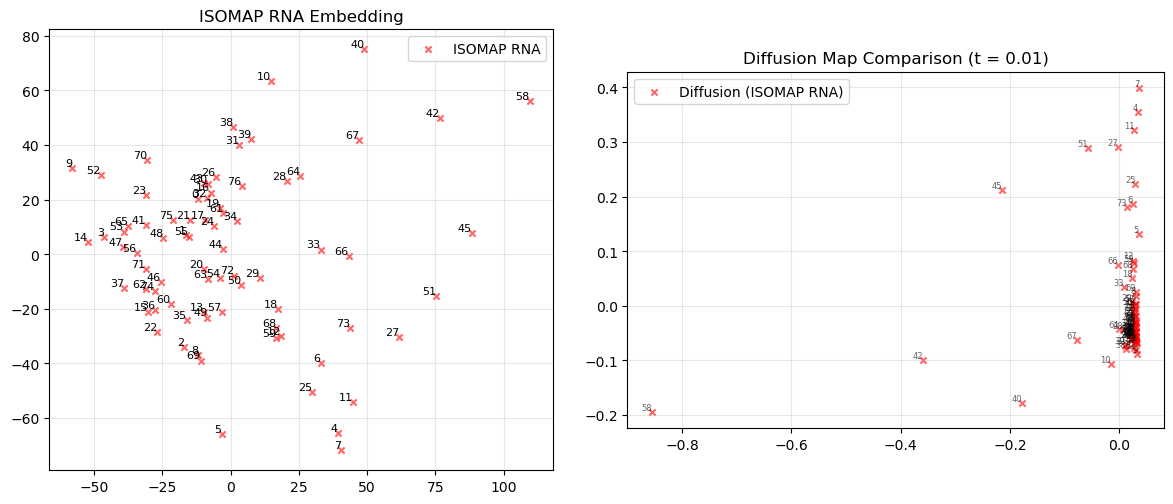

In [24]:
# Diffusion Map of ISOMAP RPPA data and the original RPPA data


# Fit
model_isomap_rna = diffusion_map_fit(isomap_embedding_rna, n_components=2)
model_rna = diffusion_map_fit(X_rna, n_components=2)
# --- Plot diffusion maps of ISOMAP RPPA and original RPPA data ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ===== (1) Left panel: ISOMAP RPPA embedding =====
ax = axes[0]
sc1 = ax.scatter(isomap_embedding_rna[:, 0], isomap_embedding_rna[:, 1],
                 c="red", marker="x", s=20, alpha=0.6, label="ISOMAP RNA")
for i in range(len(X_rna)):
    ax.text(isomap_embedding_rna[i, 0], isomap_embedding_rna[i, 1],
            str(i), fontsize=8, ha='right', va='bottom')

ax.set_title("ISOMAP RNA Embedding")
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='best')

# ===== (2) Right panel: Diffusion Map comparison =====
t = 0.01
Diff_isomap_RNA = diffusion_map_transform(model_isomap_rna, t)
Diff_RNA = diffusion_map_transform(model_rna, t)

ax = axes[1]
sc2 = ax.scatter(Diff_isomap_RNA[:, 0], Diff_isomap_RNA[:, 1],
                 c="red", marker="x", s=20, alpha=0.6, label="Diffusion (ISOMAP RNA)")
# sc3 = ax.scatter(Diff_RNA[:, 0], Diff_RNA[:, 1],
#                  c="blue", marker="o", s=20, alpha=0.6, label="Diffusion (Original z-scored RNA)")

# Number labels
for i in range(len(X_rna)):
    ax.text(Diff_isomap_RNA[i, 0], Diff_isomap_RNA[i, 1], str(i),
            fontsize=6, alpha = 0.6, ha='right', va='bottom')
#     ax.text(Diff_RNA[i, 0], Diff_RNA[i, 1], str(i),
#             fontsize=6, alpha = 0.6, ha='left', va='bottom')

ax.set_title(f"Diffusion Map Comparison (t = {t})")
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='best')  

plt.tight_layout()
plt.show()

In [25]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


c:\Users\Norman\miniconda3\envs\erdos_ds_environment\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


The shape of umap_embedding_rppa is: (77, 2)
The shape of umap_embedding_rna is: (77, 2)


c:\Users\Norman\miniconda3\envs\erdos_ds_environment\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Norman\AppData\Local\Temp\ipykernel_19408\4218815428.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0].scatter(umap_embedding_rppa[:, 0], umap_embedding_rppa[:, 1], c="blue", cmap='Spectral', alpha=0.7)
C:\Users\Norman\AppData\Local\Temp\ipykernel_19408\4218815428.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1].scatter(umap_embedding_rna[:, 0], umap_embedding_rna[:, 1], c="red", cmap='Spectral', alpha=0.7)


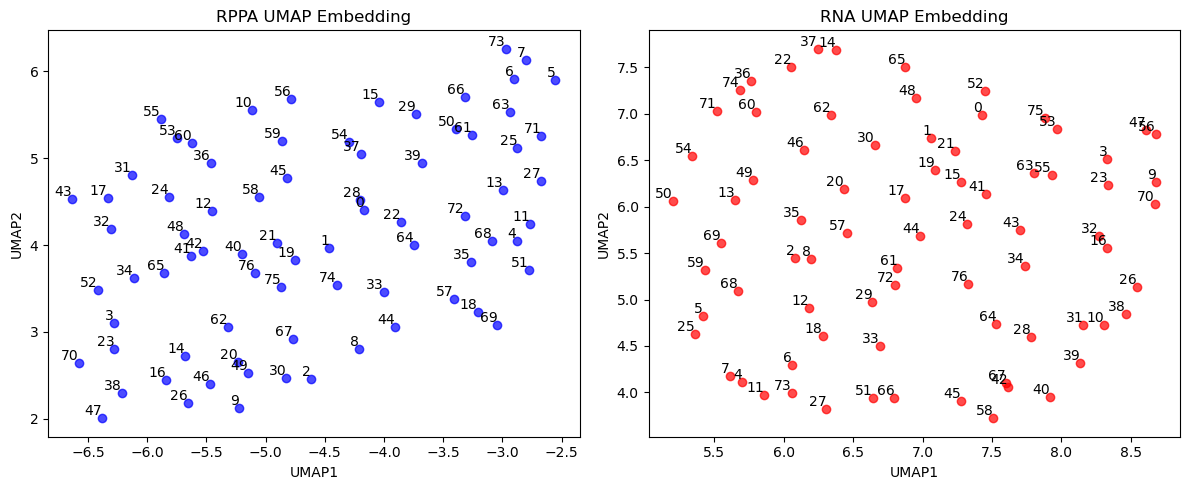

In [26]:
# visualize RPPA and RNA by UMAP
import umap

# UMAP on RPPA data
umap_rppa = umap.UMAP(n_components=2, random_state=0)
umap_embedding_rppa = umap_rppa.fit_transform(X_rppa)
print("The shape of umap_embedding_rppa is:", umap_embedding_rppa.shape)

# UMAP on RNA data
umap_rna = umap.UMAP(n_components=2, random_state=0)
umap_embedding_rna = umap_rna.fit_transform(X_rna)
print("The shape of umap_embedding_rna is:", umap_embedding_rna.shape)

# Plot UMAP embeddings side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# RPPA UMAP
axes[0].scatter(umap_embedding_rppa[:, 0], umap_embedding_rppa[:, 1], c="blue", cmap='Spectral', alpha=0.7)
axes[0].set_title("RPPA UMAP Embedding")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

# Number labels
for i in range(len(X_rppa)):
    axes[0].text(umap_embedding_rppa[i, 0], umap_embedding_rppa[i, 1],
            str(i), fontsize=10, ha='right', va='bottom')
# RNA UMAP
axes[1].scatter(umap_embedding_rna[:, 0], umap_embedding_rna[:, 1], c="red", cmap='Spectral', alpha=0.7)
axes[1].set_title("RNA UMAP Embedding")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

# Number labels
for i in range(len(X_rna)):
    axes[1].text(umap_embedding_rna[i, 0], umap_embedding_rna[i, 1],
            str(i), fontsize=10, ha='right', va='bottom')
plt.tight_layout()
plt.show()



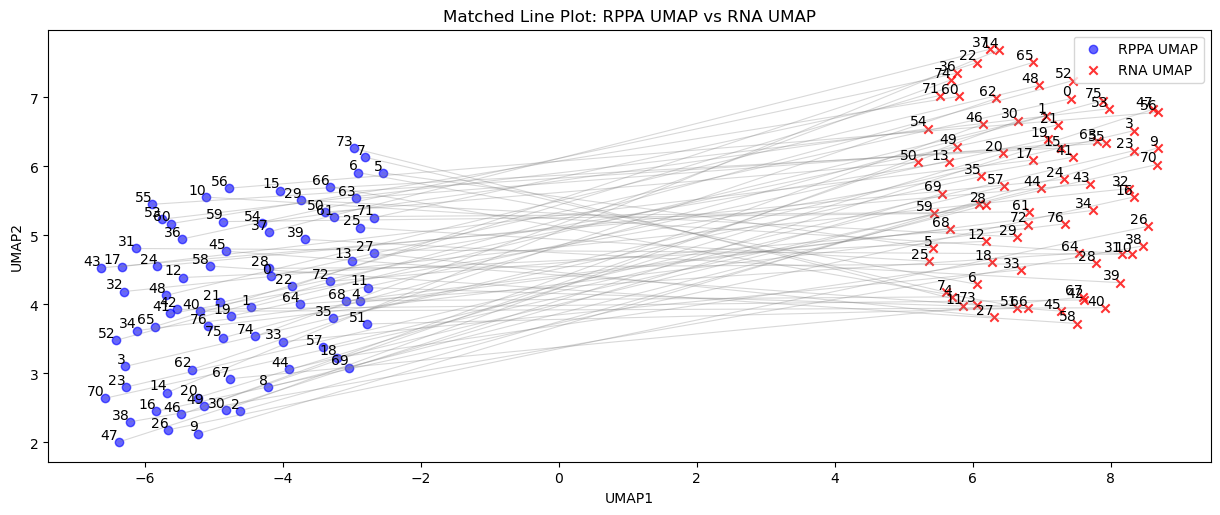

In [27]:
# matched line plot for UMAP embeddings between RPPA and RuntimeWarning

plt.figure(figsize=(15, 18))
plt.scatter(umap_embedding_rppa[:, 0], umap_embedding_rppa[:, 1], c="blue", alpha=0.6, label='RPPA UMAP')
plt.scatter(umap_embedding_rna[:, 0], umap_embedding_rna[:, 1], c="red", marker='x', alpha=0.8, label='RNA UMAP')
for i in range(0, len(X_rppa), 1):
    plt.plot([umap_embedding_rppa[i, 0], umap_embedding_rna[i, 0]],
             [umap_embedding_rppa[i, 1], umap_embedding_rna[i, 1]],
             color='gray', alpha=0.3, linewidth=0.8)
    
# Number labels
for i in range(len(X_rppa)):
    plt.text(umap_embedding_rna[i, 0], umap_embedding_rna[i, 1],
             str(i), fontsize=10, ha='right', va='bottom')
    plt.text(umap_embedding_rppa[i, 0], umap_embedding_rppa[i, 1],
             str(i), fontsize=10, ha='right', va='bottom')
plt.title("Matched Line Plot: RPPA UMAP vs RNA UMAP")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

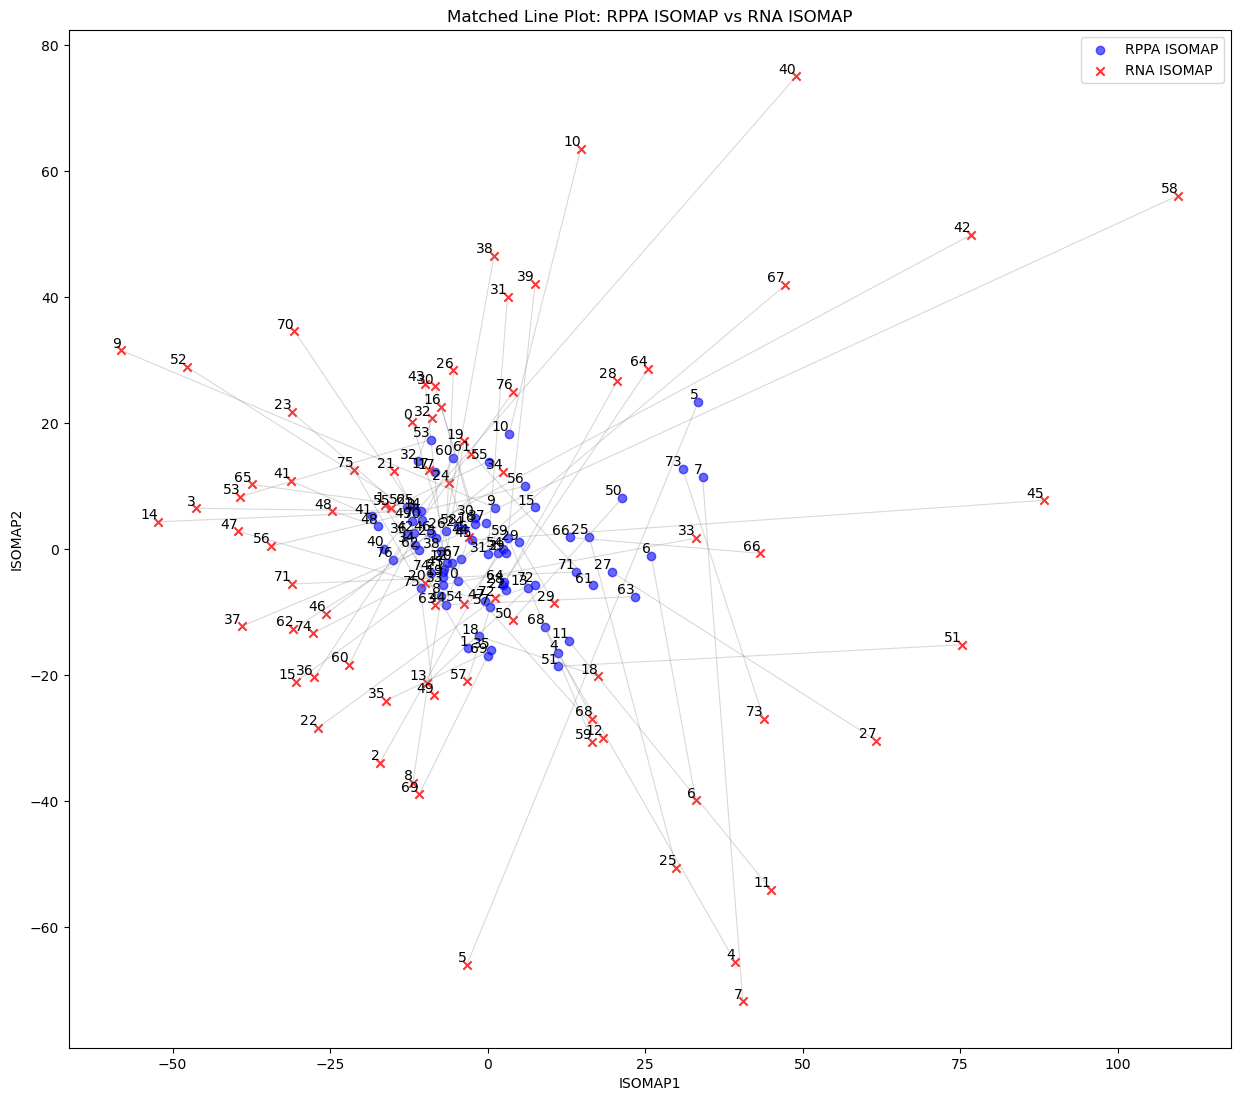

In [28]:
# matched line plot for ISOMAP embeddings between RPPA and RNA
plt.figure(figsize=(15, 18))
plt.scatter(isomap_embedding_rppa[:, 0], isomap_embedding_rppa[:, 1], c="blue", alpha=0.6, label='RPPA ISOMAP')
plt.scatter(isomap_embedding_rna[:, 0], isomap_embedding_rna[:, 1], c="red", marker='x', alpha=0.8, label='RNA ISOMAP')
for i in range(0, len(X_rppa), 1):
    plt.plot([isomap_embedding_rppa[i, 0], isomap_embedding_rna[i, 0]],
             [isomap_embedding_rppa[i, 1], isomap_embedding_rna[i, 1]],
             color='gray', alpha=0.3, linewidth=0.8)
# Number labels
for i in range(len(X_rppa)):
    plt.text(isomap_embedding_rna[i, 0], isomap_embedding_rna[i, 1],
             str(i), fontsize=10, ha='right', va='bottom')
    plt.text(isomap_embedding_rppa[i, 0], isomap_embedding_rppa[i, 1],
             str(i), fontsize=10, ha='right', va='bottom')
plt.title("Matched Line Plot: RPPA ISOMAP vs RNA ISOMAP")
plt.xlabel("ISOMAP1")
plt.ylabel("ISOMAP2")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In the following section, we will load the clinical data that contains survival times of the patients. The loaded file is "data_clinical_patient.txt". We focus on the analysis of the survivial time. 

In [29]:
# Clinical data (time, event)
clin = pd.read_csv("../glioblastoma/gbm_tcga_pan_can_atlas_2018/data_clinical_patient.txt", sep="\t", comment="#")
print("Shape of clinical data:", clin.shape)

clin_sub = clin[clin["PATIENT_ID"].isin(common_samples)].copy()
print("Shape of clinical data in common_genes rows:", clin_sub.shape)
# clin_common = clin.loc[common_samples]

Shape of clinical data: (585, 38)
Shape of clinical data in common_genes rows: (0, 38)


In [30]:
common_samples[0]

'TCGA-02-2485-01'

In [31]:
subset = clin[clin["PATIENT_ID"].isin([x[:12] for x in common_samples])]
print("the shape of subset:", subset.shape)
subset.head()

the shape of subset: (75, 38)


,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL
3,TCGA-02-2485,GBM_IDHwt,GBM,521ea765-1bd1-423d-a75d-091243df37a9,53.0,Male,NaN,NaN,470.0,-19494.0,...,Yes,0:LIVING,15.451885,0:ALIVE OR DEAD TUMOR FREE,15.451885,NaN,NaN,1:PROGRESSION,6.115001,AFR_ADMIX
11,TCGA-06-1804,GBM_IDHwt,GBM,9348e446-0e43-4210-b07e-c534980cbf62,81.0,Female,NaN,NaN,414.0,-29802.0,...,Yes,1:DECEASED,13.610810,1:DEAD WITH TUMOR,13.610810,NaN,NaN,1:PROGRESSION,13.610810,EUR
14,TCGA-06-2557,GBM_IDHwt,GBM,6c28f086-6a25-40b6-93eb-bba0014acda6,76.0,Male,NaN,NaN,33.0,-27980.0,...,Yes,1:DECEASED,1.084920,1:DEAD WITH TUMOR,1.084920,NaN,NaN,1:PROGRESSION,1.084920,AFR_ADMIX
15,TCGA-06-2558,GBM_IDHwt,GBM,cf286533-5c8a-40f3-9c69-f46264c7893b,75.0,Female,NaN,NaN,23.0,-27511.0,...,Yes,1:DECEASED,12.493014,NaN,12.493014,NaN,NaN,0:CENSORED,12.493014,ADMIX
16,TCGA-06-2559,GBM_IDHwt,GBM,ca893d12-3d6c-4e6f-b0e7-7f4eb8bb724b,83.0,Male,NaN,NaN,150.0,-30580.0,...,Yes,1:DECEASED,4.931453,1:DEAD WITH TUMOR,4.931453,NaN,NaN,1:PROGRESSION,4.931453,EUR_ADMIX


In [32]:
# clin[clin["PATIENT_ID"] == "TCGA-02-2485"]
subset[["OS_STATUS", "OS_MONTHS"]].isna().sum()

OS_STATUS    0
OS_MONTHS    0
dtype: int64

In [33]:
print(subset.isna().sum())

no_nan_cols = subset.columns[subset.notna().all()]
print("Columns without NaN values:", no_nan_cols)
subset_no_nan = subset[no_nan_cols]
subset_no_nan.head(10)

PATIENT_ID                                     0
SUBTYPE                                        7
CANCER_TYPE_ACRONYM                            0
OTHER_PATIENT_ID                              14
AGE                                           14
SEX                                           14
AJCC_PATHOLOGIC_TUMOR_STAGE                   75
AJCC_STAGING_EDITION                          75
DAYS_LAST_FOLLOWUP                            14
DAYS_TO_BIRTH                                 14
DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS          14
ETHNICITY                                     23
FORM_COMPLETION_DATE                          14
HISTORY_NEOADJUVANT_TRTYN                     14
ICD_10                                        14
ICD_O_3_HISTOLOGY                             14
ICD_O_3_SITE                                  14
INFORMED_CONSENT_VERIFIED                     14
NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT       74
PATH_M_STAGE                                  75
PATH_N_STAGE        

,PATIENT_ID,CANCER_TYPE_ACRONYM,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL
3,TCGA-02-2485,GBM,Yes,0:LIVING,15.451885,15.451885,1:PROGRESSION,6.115001,AFR_ADMIX
11,TCGA-06-1804,GBM,Yes,1:DECEASED,13.610810,13.610810,1:PROGRESSION,13.610810,EUR
14,TCGA-06-2557,GBM,Yes,1:DECEASED,1.084920,1.084920,1:PROGRESSION,1.084920,AFR_ADMIX
15,TCGA-06-2558,GBM,Yes,1:DECEASED,12.493014,12.493014,0:CENSORED,12.493014,ADMIX
16,TCGA-06-2559,GBM,Yes,1:DECEASED,4.931453,4.931453,1:PROGRESSION,4.931453,EUR_ADMIX
18,TCGA-06-2562,GBM,Yes,1:DECEASED,12.558766,12.558766,1:PROGRESSION,4.964329,EUR
19,TCGA-06-2563,GBM,Yes,0:LIVING,30.640760,30.640760,1:PROGRESSION,18.213499,EUR
20,TCGA-06-2564,GBM,Yes,0:LIVING,5.950620,5.950620,0:CENSORED,5.950620,EUR
21,TCGA-06-2565,GBM,Yes,1:DECEASED,16.635434,16.635434,1:PROGRESSION,5.851991,SAS_ADMIX
23,TCGA-06-2567,GBM,Yes,1:DECEASED,4.372555,4.372555,1:PROGRESSION,4.372555,EUR


| Column                     | Meaning                       | Biological/Clinical Use           |
| -------------------------- | ----------------------------- | --------------------------------- |
| `PATIENT_ID`               | Unique identifier             | Used for merging data             |
| `CANCER_TYPE_ACRONYM`      | Tumor type code               | Distinguishes cancer cohorts      |
| `IN_PANCANPATHWAYS_FREEZE` | Inclusion flag                | QC for curated PanCancer datasets |
| `OS_STATUS`                | Alive or deceased             | Overall survival endpoint         |
| `OS_MONTHS`                | Survival time                 | Quantitative OS measure           |
| `DSS_MONTHS`               | Cancer-specific survival time | Focused on tumor-caused deaths    |
| `PFS_STATUS`               | Progressed or not             | Disease progression endpoint      |
| `PFS_MONTHS`               | Time to progression           | Tumor control duration            |
| `GENETIC_ANCESTRY_LABEL`   | Germline ancestry group       | Population stratification         |



In [34]:
subset_no_nan.describe()

,OS_MONTHS,DSS_MONTHS,PFS_MONTHS
count,75.000000,75.000000,75.000000
mean,13.369716,13.369716,8.204622
std,10.459376,10.459376,8.178727
min,0.197258,0.197258,0.197258
25%,5.079396,5.079396,3.797219
50%,11.736858,11.736858,5.490351
75%,16.618996,16.618996,9.336884
max,47.933721,47.933721,47.933721


In [35]:
X_rna[:10]

array([[ 7.74200846e-02, -4.69367199e-03, -6.90796616e-01, ...,
         1.00255788e-02, -3.19575028e-01, -4.66522766e-01],
       [-6.66483399e-01, -4.64542014e-01, -4.79288958e-01, ...,
        -3.13051309e-01,  1.30075795e+00, -2.33300358e-01],
       [-6.59170231e-03,  1.11584006e+00,  1.11363782e-01, ...,
        -6.20164658e-02,  6.70874488e-01, -1.13023808e+00],
       ...,
       [-1.24394758e+00, -8.98500826e-01,  1.18083215e+00, ...,
        -5.70053633e-01,  4.86368325e+00, -1.18033392e+00],
       [ 1.95351787e+00,  4.93850508e-01,  7.03555803e-02, ...,
        -5.99479851e-01,  6.05292430e-02, -5.61522118e-01],
       [-8.51636112e-01, -9.98373492e-01, -7.09352728e-01, ...,
        -1.15848310e+00, -1.16485113e-01, -3.02686054e-01]],
      shape=(10, 2000))

In [37]:
# X_rppa = R_z.T.values
# X_rna = rna_hv_z.values

R_z.head() 

Rppa_z = R_z.copy()
Rppa_z.columns = [c[:12] for c in R_z.columns]
Rppa_z.head()

# count how many times each patient ID appears in the columns
counts = pd.Series(Rppa_z.columns).value_counts()
duplicates = counts[counts > 1]
print("Patients with multiple samples:", len(duplicates))
print(duplicates.head())

Rppa_z = Rppa_z.groupby(axis =  1, level = 0).mean()
counts_after = pd.Series(Rppa_z.columns).value_counts()
duplicates_after = counts_after[counts_after > 1]
print("Patients with multiple samples after averaging:", len(duplicates_after))
# Double-check uniqueness
print("Total columns:", len(Rppa_z.columns))
print("Unique patient IDs:", len(set(Rppa_z.columns)))
Rppa_z.head()

Patients with multiple samples: 2
TCGA-06-0125    2
TCGA-06-0190    2
Name: count, dtype: int64
Patients with multiple samples after averaging: 0
Total columns: 75
Unique patient IDs: 75


C:\Users\Norman\AppData\Local\Temp\ipykernel_19408\3952801455.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Rppa_z = Rppa_z.groupby(axis =  1, level = 0).mean()


,TCGA-02-2485,TCGA-06-0125,TCGA-06-0129,TCGA-06-0130,TCGA-06-0171,TCGA-06-0190,TCGA-06-0210,TCGA-06-0221,TCGA-06-0238,TCGA-06-0644,...,TCGA-32-5222,TCGA-41-3915,TCGA-41-4097,TCGA-41-5651,TCGA-76-4926,TCGA-76-4927,TCGA-76-4928,TCGA-76-4929,TCGA-76-4931,TCGA-76-4932
Composite.Element.REF,,,,,,,,,,,,,,,,,,,,,
YWHAE|14-3-3_epsilon,-0.241356,-0.283605,0.075345,-1.814799,-0.561926,-0.402548,0.426536,-0.039402,1.984422,-2.247830,...,0.044433,-0.426718,-1.951396,-1.310738,1.481156,-0.737058,2.040295,0.508829,-0.091347,-0.192332
EIF4EBP1|4E-BP1,-0.894083,-1.074168,0.780605,-0.126373,-0.273959,0.441866,-0.415201,-0.625677,1.070077,0.347677,...,-0.883691,-0.614352,-1.261559,-0.013398,0.344532,-1.571880,-0.281397,-0.180545,-0.608656,-0.848218
EIF4EBP1|4E-BP1_pS65,0.155500,-0.698580,0.292935,-0.184541,-1.475107,-1.283444,-1.514539,1.522307,-0.388163,-0.676662,...,-0.407163,-0.913166,0.813328,0.055534,-0.487040,-0.744317,-0.599588,-0.367569,0.522021,-0.046949
EIF4EBP1|4E-BP1_pT37T46,1.059116,-1.014957,0.408977,-0.756241,-2.908079,-1.478491,-0.521058,-0.289051,-1.710816,0.318524,...,-0.132751,0.132299,0.295865,1.655223,-0.611185,-0.423641,-1.734853,0.729696,1.829087,1.383109
TP53BP1|53BP1,-0.386054,0.376513,0.464245,-0.612277,-2.352663,-2.584039,0.705603,-0.275147,0.177327,-0.403355,...,-0.271454,-0.395103,-0.171704,-0.841622,-0.697600,-0.391619,-1.913398,0.498350,1.396104,0.655957


In [50]:
# subset_no_nan must have PATIENT_ID, OS_MONTHS, OS_STATUS (or OS_EVENT)
clin = subset_no_nan.copy()
clin.columns = [c.upper() for c in clin.columns]

# If OS_EVENT not built yet:
if "OS_EVENT" not in clin.columns:
    clin["OS_EVENT"] = clin["OS_STATUS"].str.upper().map(
        lambda s: 1 if isinstance(s,str) and ("DECEASED" in s or s.startswith("1")) else 0
    )

# Keep only needed columns
clin = clin[["PATIENT_ID","OS_MONTHS","OS_EVENT"]].dropna(subset=["OS_MONTHS","OS_EVENT"])
clin["OS_MONTHS"] = pd.to_numeric(clin["OS_MONTHS"], errors="coerce")
clin.head()

,PATIENT_ID,OS_MONTHS,OS_EVENT
3,TCGA-02-2485,15.451885,0
11,TCGA-06-1804,13.610810,1
14,TCGA-06-2557,1.084920,1
15,TCGA-06-2558,12.493014,1
16,TCGA-06-2559,4.931453,1


In [39]:
# Rppa_z: rows = proteins, columns = 12-char patient IDs (already cleaned)
common_patients = pd.Index(Rppa_z.columns).intersection(clin["PATIENT_ID"])

# Subset & orient: rows = patients, cols = proteins
rppa_mat = Rppa_z.loc[:, common_patients].T

# Clinical aligned to same order
clin_rppa = clin.set_index("PATIENT_ID").loc[common_patients] # align clinical to rppa patients
df_rppa = pd.concat([clin_rppa[["OS_MONTHS","OS_EVENT"]], rppa_mat], axis=1).dropna(subset=["OS_MONTHS","OS_EVENT"])
print("RPPA Cox matrix:", df_rppa.shape)  # (n_patients, 2 + n_proteins)




RPPA Cox matrix: (75, 193)


In [40]:
# RNA
Rna_z = rna_hv_z.copy()
print("The shape of Rna_z before changing columns:", Rna_z.shape)
Rna_z.head()
Rna_z.index = [c[:12] for c in Rna_z.index]
print(Rna_z.head())

# Collapse duplicate patient IDs by averaging
Rna_z = Rna_z.groupby(level = 0).mean()
common_patients_rna = pd.Index(Rna_z.index).intersection(subset_no_nan["PATIENT_ID"])
Rna_sub = Rna_z.loc[common_patients_rna]
clin_rna = subset_no_nan.set_index("PATIENT_ID").loc[common_patients_rna]

# merge into one dataframe
df_rna = pd.concat([clin_rna[["OS_MONTHS","OS_EVENT"]], Rna_sub], axis=1)
print("RNA Cox matrix:", df_rna.shape)




The shape of Rna_z before changing columns: (77, 2000)
Hugo_Symbol       GFAP       CLU    CHI3L1      SPP1       FN1    COL1A2  \
TCGA-02-2485  0.077420 -0.004694 -0.690797 -0.733124 -0.287143 -0.301623   
TCGA-06-0125 -0.666483 -0.464542 -0.479289 -0.699100  0.036744 -0.285550   
TCGA-06-0125 -0.006592  1.115840  0.111364 -0.046714  1.417706 -0.173993   
TCGA-06-0129 -0.311836 -1.084401 -0.690002  0.305301 -0.545549 -0.353495   
TCGA-06-0130 -1.182535 -0.889662 -0.533227 -0.261240  1.281569  5.405930   

Hugo_Symbol     TUBA1A     GAPDH     SPARC      ACTB  ...   FAM181B      HEXA  \
TCGA-02-2485 -0.010284 -0.797948 -0.682514 -0.422689  ...  1.406938 -1.462865   
TCGA-06-0125 -0.550142 -0.273625 -0.441916  0.246942  ... -0.109797 -0.852217   
TCGA-06-0125 -0.704222  1.700813 -0.684660  1.522284  ... -0.957502 -0.186781   
TCGA-06-0129 -0.466914 -1.441897 -1.095048 -1.264842  ... -0.133362 -0.868531   
TCGA-06-0130 -1.099356 -0.562640  0.648774  1.595436  ... -1.810141  2.377099   

H

In [41]:
from lifelines import CoxPHFitter
from sklearn.decomposition import PCA



# Using direct features for Cox regression (RNA)
# cph = CoxPHFitter(penalizer=1)
# cph.fit(df_rna, duration_col="OS_MONTHS", event_col="OS_EVENT")
# cph.print_summary()




In [42]:
# Using PCA components for Cox regression 
X_rna = df_rna.drop(columns=["OS_MONTHS","OS_EVENT"])
pca = PCA(n_components=10)
X_rna_pca = pd.DataFrame(
    pca.fit_transform(X_rna),
    index=X_rna.index,
    columns=[f"PC{i+1}" for i in range(10)]
)

df_rna_pca = pd.concat([df_rna[["OS_MONTHS","OS_EVENT"]], X_rna_pca], axis=1)

cph = CoxPHFitter()
cph.fit(df_rna_pca, duration_col="OS_MONTHS", event_col="OS_EVENT")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 75 total observations, 19 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
      baseline estimation = breslow
   number of observations = 75
number of events observed = 56
   partial log-likelihood = -174.24
         time fit was run = 2025-10-26 23:15:50 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PC1        0.01      1.01      0.01           -0.00            0.02                1.00                1.02
PC2        0.03      1.03      0.01            0.01            0.04                1.01                1.04
PC3        0.01      1.01      0.01           -0.01            0.03                0.99                1.03
PC4       -0.02      0.98      0.01           -0.04            0.01                0.96                1.01
PC5       -0.01      0.99      0.01           -0.04            0.01                0.96                1.01
PC6        0.01      1.01      0.02           -0.02            0.05                0.98                1.05
PC7       -0.03      0.97      0.02           -0.06            0.01                0.94                1.01
PC8       -0.05      0.95      0.02           -0.10           -0.01                0.91                0.99
PC9       -0.01      0.99      0.02           -0.05            0.03                0.96                1.03
PC10      -0.02      0.98      0.02           -0.07            0.02                0.94                1.02

           cmp to     z      p  -log2(p)
covariate                               
PC1          0.00  1.52   0.13      2.96
PC2          0.00  3.06 <0.005      8.83
PC3          0.00  0.76   0.45      1.17
PC4          0.00 -1.47   0.14      2.83
PC5          0.00 -0.95   0.34      1.55
PC6          0.00  0.69   0.49      1.03
PC7          0.00 -1.33   0.18      2.44
PC8          0.00 -2.40   0.02      5.95
PC9          0.00 -0.28   0.78      0.36
PC10         0.00 -1.09   0.28      1.85
---
Concordance = 0.69
Partial AIC = 368.49
log-likelihood ratio test = 20.38 on 10 df
-log2(p) of ll-ratio test = 5.27

From this Cox analysis of Top 10 Principal Component Embedding of RNA data, we see that PC2 and PC8 has the most significant influence on the OS_MONTHs since the p-value of PC2 is only 0.0096 and PC8 is only 0.047, both < 0.05.


In [43]:
df_rna_pca.head()

,OS_MONTHS,OS_EVENT,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
TCGA-02-2485,15.451885,0,-10.058245,-12.425031,0.437690,7.268891,4.423840,-5.965115,-6.558613,1.782300,1.117602,-3.739849
TCGA-06-0125,47.604958,1,-12.730573,12.486298,1.392346,12.284080,-2.411481,2.451106,5.625110,5.029099,4.541530,-4.181031
TCGA-06-0129,33.665384,1,-26.178527,-9.170625,-8.182365,-16.265012,6.220765,-16.344596,-3.328996,2.630691,8.413614,7.813792
TCGA-06-0130,12.953283,1,17.013874,30.018651,-19.455527,-15.686658,9.698883,-5.584101,-6.588033,-9.311092,-7.048342,4.940421
TCGA-06-0171,13.117664,1,0.855801,43.386111,6.017686,-27.552830,-6.850052,-10.121108,-5.157375,12.618973,6.100653,-5.088322


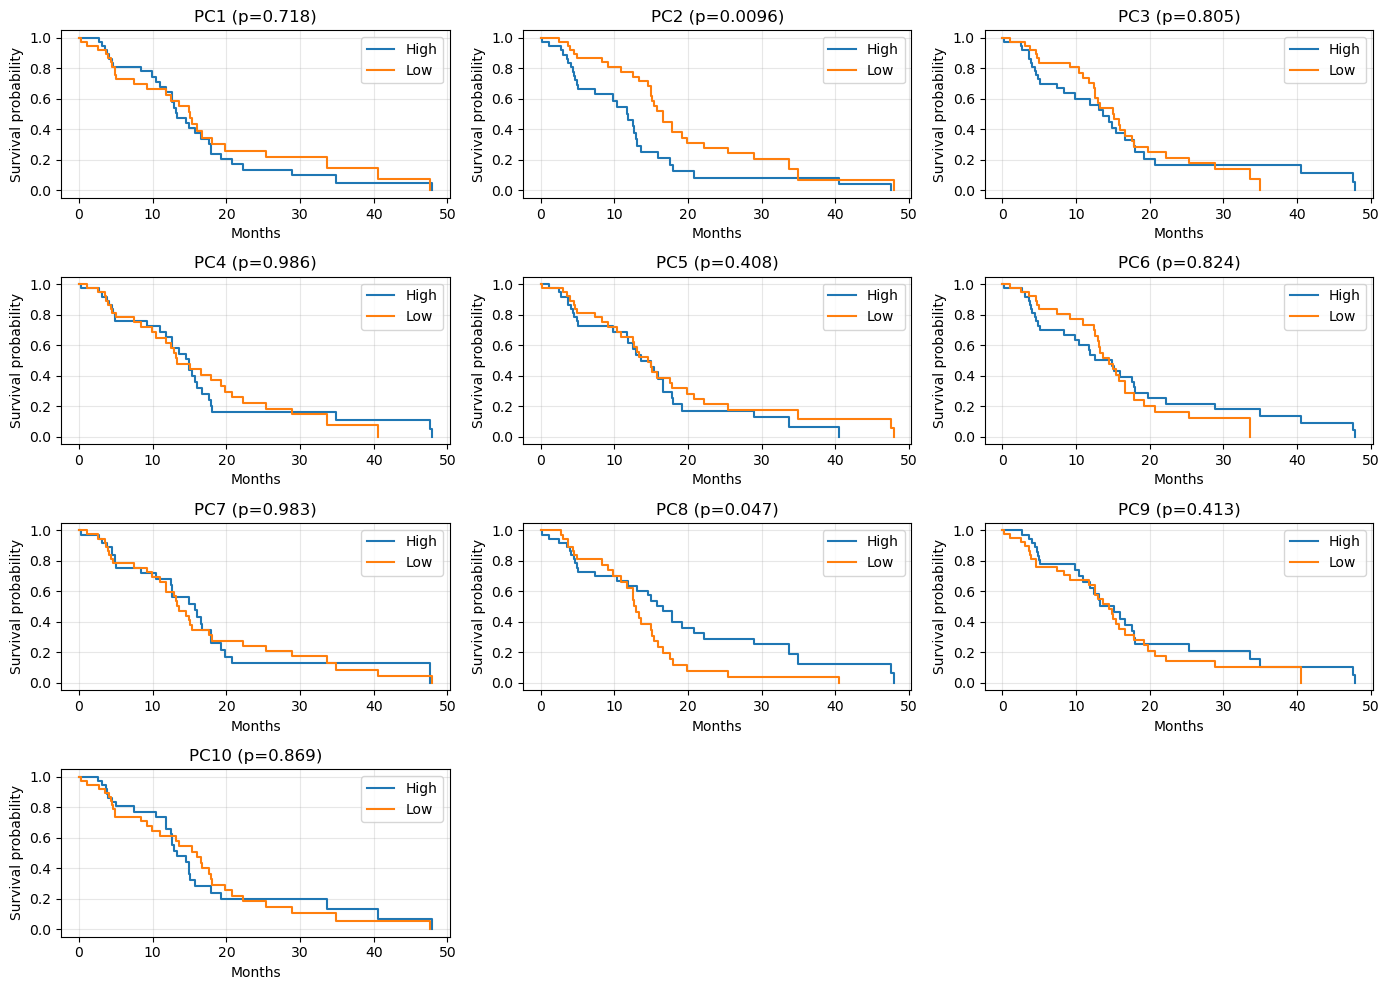

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

def km_plot_median(df, feature, ax=None, time_col="OS_MONTHS", event_col="OS_EVENT", title=None):
    d = df[[time_col, event_col, feature]].dropna()
    med = d[feature].median()
    high = d[d[feature] > med]
    low  = d[d[feature] <= med]

    kmh, kml = KaplanMeierFitter(), KaplanMeierFitter()
    kmh.fit(high[time_col], high[event_col], label="High")
    kml.fit(low[time_col],  low[event_col],  label="Low")

    lr = logrank_test(high[time_col], low[time_col], high[event_col], low[event_col])
    pval = lr.p_value

    if ax is None:
        ax = plt.gca()

    kmh.plot_survival_function(ax=ax, ci_show=False)
    kml.plot_survival_function(ax=ax, ci_show=False)
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival probability")
    ax.set_title(title or f"{feature} (p={pval:.3g})")
    ax.grid(alpha=0.3)

    return pval


# ==== Plot 10 PCs in a 4x3 grid ====
fig, axes = plt.subplots(4, 3, figsize=(14, 10))
axes = axes.flatten()

for i in range(10):  # PC1 ... PC10
    km_plot_median(df_rna_pca, feature=f"PC{i+1}", ax=axes[i])

# Hide extra empty subplots
for j in range(10, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [46]:
rppa_mat
clin_rppa[["OS_MONTHS","OS_EVENT"]]
# df_rppa["OS_EVENT"].dtype

print("check NaNs in df:",df_rppa.isna().sum().sum())
df_rppa.describe()

check NaNs in df: 0


,OS_MONTHS,OS_EVENT,YWHAE|14-3-3_epsilon,EIF4EBP1|4E-BP1,EIF4EBP1|4E-BP1_pS65,EIF4EBP1|4E-BP1_pT37T46,TP53BP1|53BP1,ACACA ACACB|ACC_pS79,ACACA|ACC1,AKT1 AKT2 AKT3|Akt,...,YWHAB|14-3-3_beta,YWHAZ|14-3-3_zeta,ACVRL1|ACVRL1,DIRAS3|DIRAS3,ANXA1|Annexin-1,PREX1|PREX1,ERCC1|ERCC1,MSH2|MSH2,MSH6|MSH6,DIABLO|Smac
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,...,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,13.369716,0.746667,0.009149,0.008431,0.026427,0.033246,0.029434,0.042169,0.039480,0.017125,...,-0.020106,-0.021128,0.005605,-0.011580,-0.005895,0.013412,-0.035816,0.031041,0.012807,0.010569
std,10.459376,0.437849,0.996556,0.988905,0.985874,0.975719,0.963008,0.961147,0.960495,0.986989,...,0.967544,0.963000,0.980292,0.988821,1.009620,0.988235,0.958376,0.988791,1.007319,0.997049
min,0.197258,0.000000,-3.021725,-1.723044,-1.589730,-2.908079,-2.584039,-3.203428,-3.502753,-2.843072,...,-1.846024,-1.973951,-2.046018,-2.828146,-2.349803,-2.600164,-1.525488,-2.687092,-1.868844,-1.816001
25%,5.079396,0.500000,-0.451620,-0.620014,-0.602047,-0.574811,-0.456958,-0.398570,-0.403055,-0.451398,...,-0.534421,-0.775606,-0.611346,-0.432470,-0.475673,-0.533828,-0.489944,-0.569153,-0.853275,-0.733626
50%,11.736858,1.000000,0.075345,-0.180545,-0.180459,0.105307,-0.085088,0.204938,0.101257,0.021728,...,-0.158036,-0.069696,-0.003958,-0.004007,0.135586,0.260192,-0.171061,-0.096684,-0.128790,-0.147800
75%,16.618996,1.000000,0.504127,0.569615,0.438547,0.659902,0.655783,0.519391,0.693411,0.557422,...,0.289948,0.535313,0.522131,0.383396,0.675985,0.694616,0.080078,0.838503,0.768350,0.549998
max,47.933721,1.000000,2.203266,2.592555,3.065781,2.225747,2.409071,2.544322,2.363605,2.980417,...,4.093278,2.687031,3.506239,4.506976,1.703011,1.802056,5.864843,2.140290,2.803678,3.251792


In [47]:
from lifelines import CoxPHFitter
cph = CoxPHFitter(penalizer=5)
cph.fit(df_rppa, duration_col="OS_MONTHS", event_col="OS_EVENT")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 75 total observations, 19 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
                penalizer = 5
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 75
number of events observed = 56
   partial log-likelihood = -176.32
         time fit was run = 2025-10-26 23:15:51 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
YWHAE|14-3-3_epsilon                -0.01      0.99      0.05           -0.11            0.09                0.90                1.09
EIF4EBP1|4E-BP1                      0.00      1.00      0.05           -0.10            0.10                0.91                1.11
EIF4EBP1|4E-BP1_pS65                -0.01      0.99      0.05           -0.10            0.09                0.90                1.10
EIF4EBP1|4E-BP1_pT37T46             -0.01      0.99      0.05           -0.11            0.09                0.89                1.09
TP53BP1|53BP1                       -0.01      0.99      0.05           -0.12            0.09                0.89                1.09
ACACA ACACB|ACC_pS79                -0.01      0.99      0.05           -0.11            0.09                0.89                1.10
ACACA|ACC1                          -0.01      0.99      0.05           -0.12            0.09                0.89                1.10
AKT1 AKT2 AKT3|Akt                  -0.03      0.97      0.05           -0.13            0.07                0.88                1.07
AKT1 AKT2 AKT3|Akt_pS473             0.01      1.01      0.05           -0.09            0.11                0.92                1.12
AKT1 AKT2 AKT3|Akt_pT308             0.01      1.01      0.05           -0.09            0.11                0.92                1.11
PRKAA1|AMPK_alpha                   -0.01      0.99      0.05           -0.11            0.10                0.90                1.10
PRKAA1|AMPK_pT172                   -0.01      0.99      0.05           -0.11            0.09                0.89                1.09
AR|AR                                0.00      1.00      0.05           -0.09            0.10                0.91                1.10
ASNS|ASNS                           -0.02      0.98      0.05           -0.11            0.08                0.89                1.08
ATM|ATM                             -0.00      1.00      0.05           -0.10            0.10                0.90                1.10
BAK1|Bak                             0.01      1.01      0.05           -0.09            0.11                0.91                1.11
BAX|Bax                             -0.00      1.00      0.05           -0.10            0.09                0.91                1.10
BCL2|Bcl-2                           0.01      1.01      0.05           -0.09            0.11                0.91                1.11
BCL2L1|Bcl-xL                       -0.01      0.99      0.05           -0.11            0.08                0.90                1.09
BECN1|Beclin                         0.01      1.01      0.05           -0.09            0.10                0.91                1.11
CTNNB1|beta-Catenin                 -0.02      0.98      0.05           -0.12            0.08                0.88                1.08
BID|Bid                             -0.01      0.99      0.05           -0.11            0.09                0.90                1.10
BCL2L11|Bim                          0.00      1.00      0.05           -0.10            0.10                0.91                1.11
JUN|c-Jun_pS73                       0.00      1.00      0.05           -0.10            0.10                0.91                1.10
KIT|c-Kit                            0.00      1.00      0.05           -0.09            0.10

From this Cox analysis of Top 10 Principal Component Embedding of RPPA data, we did not find any features with significant influence on the OS_MONTHs. All principal components have large p-values. 


In [48]:
X_rppa = df_rppa.drop(columns=["OS_MONTHS","OS_EVENT"])
pca = PCA(n_components=10)  # top 10 PCs
X_rppa_pca = pd.DataFrame(pca.fit_transform(X_rppa), index=X_rppa.index, columns=[f"PC{i+1}" for i in range(10)])

df_rppa_pca = pd.concat([df_rppa[["OS_MONTHS","OS_EVENT"]], X_rppa_pca], axis=1)
cph.fit(df_rppa_pca, duration_col="OS_MONTHS", event_col="OS_EVENT")
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 75 total observations, 19 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'OS_EVENT'
                penalizer = 5
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 75
number of events observed = 56
   partial log-likelihood = -183.92
         time fit was run = 2025-10-26 23:15:52 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
PC1        0.01      1.01      0.01           -0.01            0.02                0.99                1.02
PC2       -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
PC3       -0.00      1.00      0.01           -0.03            0.02                0.97                1.02
PC4        0.01      1.01      0.01           -0.02            0.04                0.98                1.04
PC5        0.00      1.00      0.02           -0.03            0.03                0.97                1.03
PC6       -0.00      1.00      0.02           -0.03            0.03                0.97                1.03
PC7       -0.00      1.00      0.02           -0.04            0.04                0.96                1.04
PC8        0.00      1.00      0.02           -0.04            0.04                0.96                1.04
PC9       -0.00      1.00      0.02           -0.05            0.04                0.95                1.04
PC10      -0.00      1.00      0.02           -0.05            0.04                0.95                1.04

           cmp to     z    p  -log2(p)
covariate                             
PC1          0.00  0.67 0.50      1.00
PC2          0.00 -0.46 0.65      0.63
PC3          0.00 -0.17 0.87      0.20
PC4          0.00  0.51 0.61      0.70
PC5          0.00  0.06 0.95      0.07
PC6          0.00 -0.03 0.98      0.03
PC7          0.00 -0.01 0.99      0.02
PC8          0.00  0.18 0.86      0.22
PC9          0.00 -0.17 0.87      0.21
PC10         0.00 -0.19 0.85      0.24
---
Concordance = 0.64
Partial AIC = 387.83
log-likelihood ratio test = 1.03 on 10 df
-log2(p) of ll-ratio test = 0.00

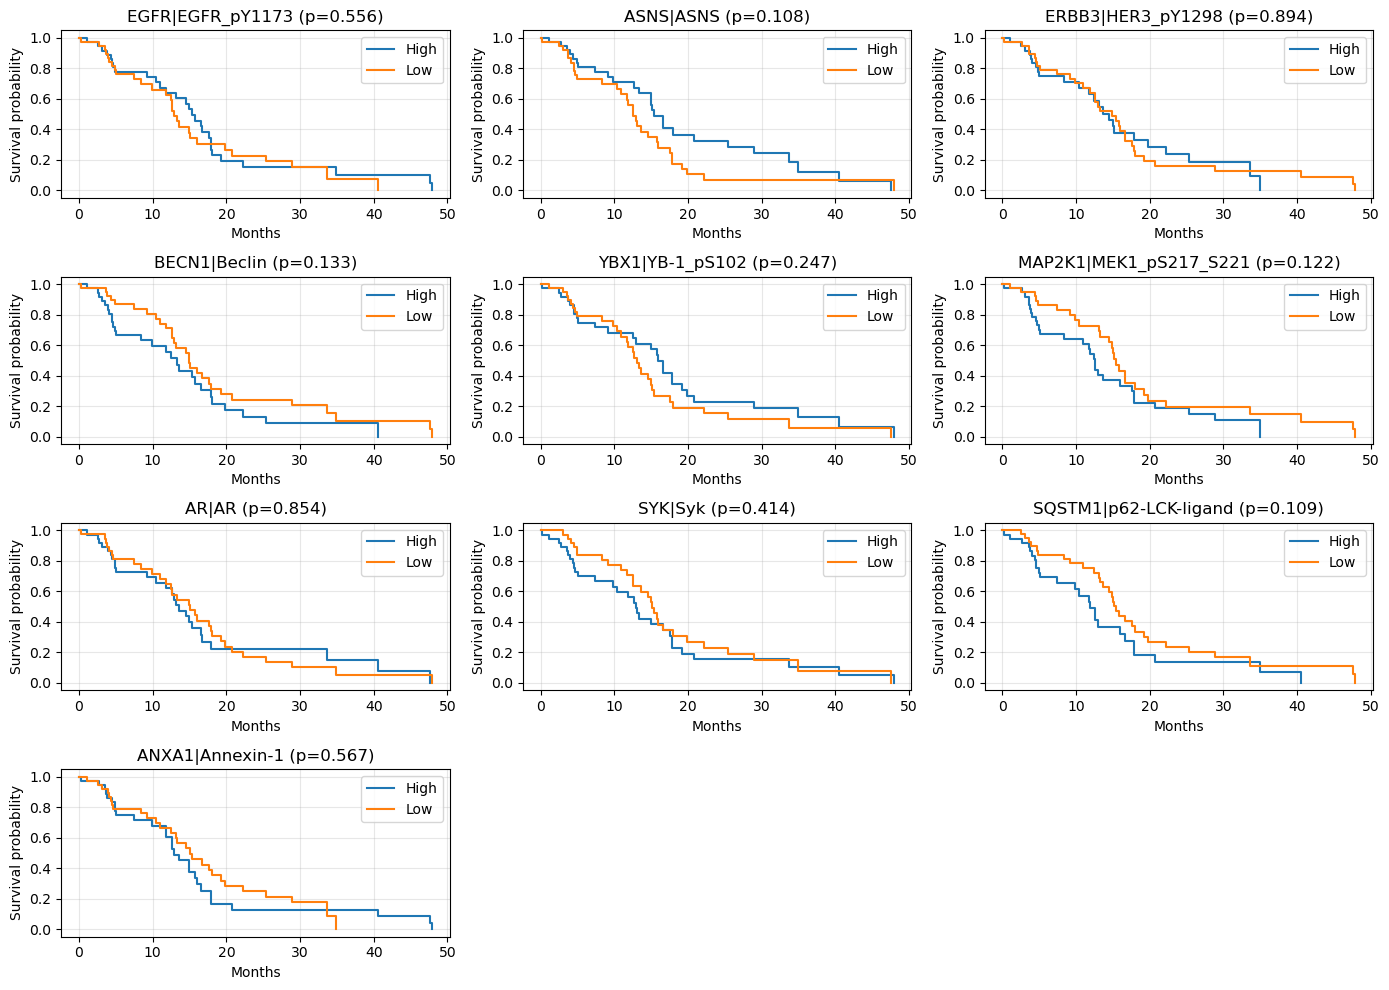

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# --- same helper as before (works for any feature) ---
def km_plot_median(df, feature, ax=None, time_col="OS_MONTHS", event_col="OS_EVENT", title=None):
    d = df[[time_col, event_col, feature]].dropna()
    med = d[feature].median()
    high = d[d[feature] > med]
    low  = d[d[feature] <= med]

    kmh, kml = KaplanMeierFitter(), KaplanMeierFitter()
    kmh.fit(high[time_col], high[event_col], label="High")
    kml.fit(low[time_col],  low[event_col],  label="Low")

    lr = logrank_test(high[time_col], low[time_col], high[event_col], low[event_col])
    pval = lr.p_value

    if ax is None:
        ax = plt.gca()
    kmh.plot_survival_function(ax=ax, ci_show=False)
    kml.plot_survival_function(ax=ax, ci_show=False)
    ax.set_xlabel("Months"); ax.set_ylabel("Survival probability")
    ax.set_title(title or f"{feature} (p={pval:.3g})")
    ax.grid(alpha=0.3)
    return pval

# -------- choose 10 RPPA features to plot --------
# Option A: top-variance proteins (simple, no screening step)
rppa_feats_all = df_rppa.columns.drop(["OS_MONTHS","OS_EVENT"])
top10_rppa = (
    df_rppa[rppa_feats_all]
    .var(axis=0)
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# (Optional) Option B: if you already ran univariate Cox and have rppa_results with a 'feature' and 'p' column:
# top10_rppa = rppa_results.sort_values("p").head(10)["feature"].tolist()

# -------- plot 10 KM curves in a 4x3 grid --------
fig, axes = plt.subplots(4, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top10_rppa):
    km_plot_median(df_rppa, feature=feat, ax=axes[i])

# Hide any leftover empty subplots (there will be 2 empty spots)
for j in range(len(top10_rppa), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
